In [4]:
rm(list = ls())
gc()
.libPaths(c("/home/minghui/R/x86_64-pc-linux-gnu-library/4.3", '/usr/local/lib/R/site-library',
'/usr/lib/R/site-library','/usr/lib/R/library'
))

library(Seurat)
library(dplyr)

library(SymSim)
library(ape)


setwd('/mnt/data00/Minghui/project_NMF/11_simlate_count/')

cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7577407,404.7,13765228,735.2,13556188,724.0
Vcells,13408171,102.3,681927824,5202.7,834826732,6369.3


In [400]:
library(Matrix)
library(harmony)

Loading required package: Rcpp



In [92]:
# true_counts_res <- readRDS('./true_counts_res.rds')
# Construct a developmental tree: a short branch Normal and a long branch Cancer


tree_text <- "(Normal:0.01,Cancer:1.0);" 

# The short Normal branch to the “normal” state that has hardly changed
# and the long Cancer branch corresponds to the “normal→cancer” continuous trajectory extending from the root.

tree <- read.tree(text = tree_text)

# Set parameters and simulate real counts
ngenes <- 4000 
true_counts_res <- SimulateTrueCounts(
  ncells_total = 18000,#     The total number of simulated cells is 6000 
#     (to ensure that there are enough cells on the long branches for subsequent
#      selection of 2000 cells at each end).
  ngenes = ngenes,
  evf_type = "continuous", # Generate continuous trajectories
  phyla = tree,
  nevf = 10,
  n_de_evf = 5,
  vary = "s",
  Sigma = 0.4,
  randseed = 123
)

# In addition, the cell development tree parameter phyla is required to define the trajectory structure.

# SymSim uses extrinsic variability factors (EVFs) to characterize biological differences between cells.
# Each cell has an EVF vector, and each gene has a corresponding gene effect vector, 
# which together determine gene expression levels.

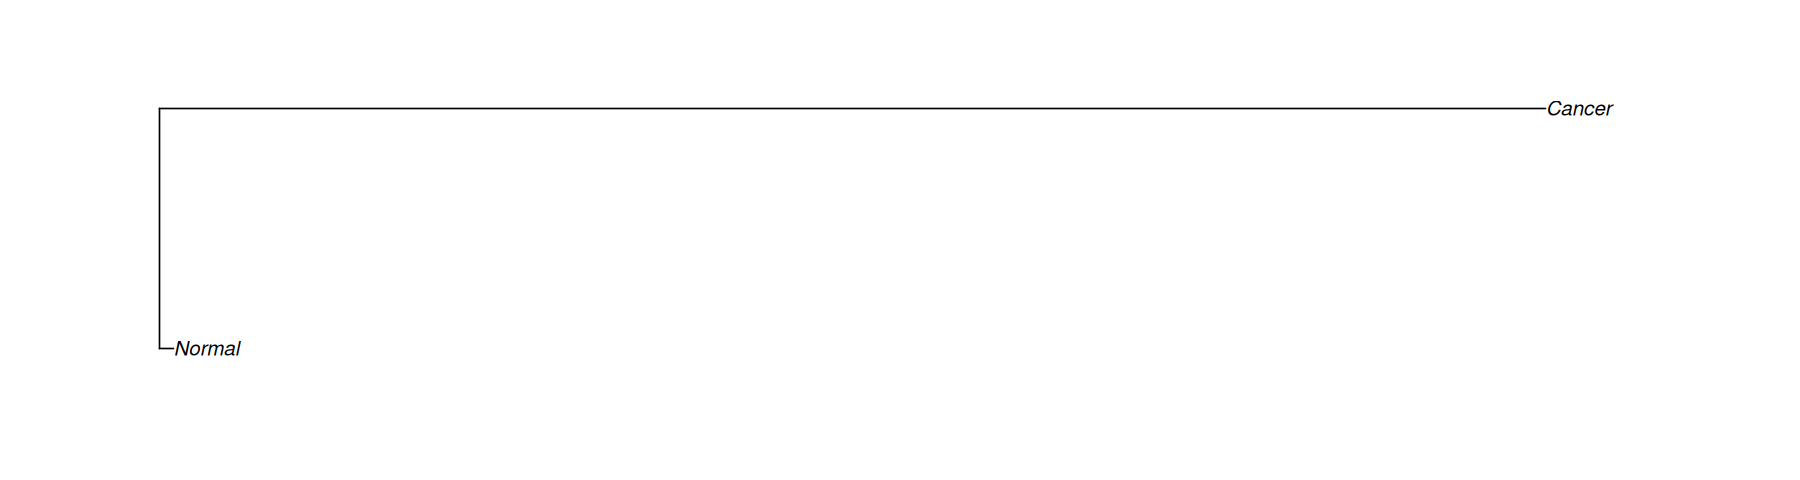

In [799]:
options(repr.plot.width =15, repr.plot.height=4)

plot(tree)

# generate first two groups

In [93]:
# True gene × cell count matrix

true_counts <- true_counts_res[[1]]

# Cell meta-information, including EVF and the branch to which the cell belongs, etc.

cell_meta <- true_counts_res[[3]]         

In [94]:
# Extract continuous trajectory information, 
# returns the "branch" (branch) and "pseudotime" 
# (relative distance/pseudotime from the root) of each cell

traj_info <- getTrajectoryGenes(cell_meta)
head(traj_info)

table(traj_info$branch)

,branch,pseudotime
,<chr>,<dbl>
cell_1,3_1,0.000000e+00
cell_2,3_1,5.617978e-05
cell_3,3_1,1.123596e-04
cell_4,3_1,1.685393e-04
cell_5,3_1,2.247191e-04
cell_6,3_1,2.808989e-04



  3_1   3_2 
  180 17820 

In [95]:
# Find the branch that extends the farthest 
# the Cancer main trajectory branch
max_pstime <- tapply(traj_info$pseudotime, traj_info$branch, max)
main_branch <- names(max_pstime)[which.max(max_pstime)]
main_branch  # e.g., "3_2"


[1] "3_2"

In [285]:
# Extract all cell indices on the main trajectory branch
cells_main_branch <- which(traj_info$branch == main_branch)
# Sort by pseudo time from smallest to largest
cells_main_branch <- cells_main_branch[order(traj_info$pseudotime[cells_main_branch])]

# Select the first 2000 (near the start of the trajectory) and the last 2000 (end)
normal_idx <- cells_main_branch[1:5000]                       # Normal cell index

cancer_idx <- cells_main_branch[(length(cells_main_branch)-4999):length(cells_main_branch)]  # cancer

# Extract the corresponding expression matrix columns

normal_counts <- true_counts[, normal_idx]
cancer_counts <- true_counts[, cancer_idx]

colnames(normal_counts) <- paste0("Cell", seq_len(ncol(normal_counts)))
rownames(normal_counts) <- paste0("Genes", seq_len(nrow(normal_counts)))

colnames(cancer_counts) <- paste0("PCell", seq_len(ncol(cancer_counts)))
rownames(cancer_counts) <- paste0("PGenes", seq_len(nrow(cancer_counts)))


In [287]:
normal_batch_meta <- data.frame(state = rep("Normal", ncol(normal_counts)))

rownames(normal_batch_meta) <- colnames(normal_counts) 


cancer_batch_meta <- data.frame(state = rep("Cancer", ncol(cancer_counts)))

rownames(cancer_batch_meta) <- colnames(cancer_counts) 

head(cancer_batch_meta)

,state
,<chr>
PCell1,Cancer
PCell2,Cancer
PCell3,Cancer
PCell4,Cancer
PCell5,Cancer
PCell6,Cancer


In [288]:
normal_seu <- CreateSeuratObject(counts = normal_counts, 
                                 project = "SymSimData", 
                                 meta.data = normal_batch_meta)

cancer_seu <- CreateSeuratObject(counts = cancer_counts, 
                                 project = "SymSimData", 
                                 meta.data = cancer_batch_meta)

seurat_obj <- merge(normal_seu, cancer_seu)

In [55]:
# #MERGE
# combined_counts <- cbind(normal_counts, cancer_counts)
# # Create state label vector for merge matrix
# cell_labels <- c(rep("Normal", ncol(normal_counts)),
#                  rep("Cancer", ncol(cancer_counts)))

# table(cell_labels)

# colnames(combined_counts) %>% tail

# meta_combined <- data.frame(State = cell_labels)
# rownames(meta_combined)  <- colnames(combined_counts) 
# tail(meta_combined)

cell_labels
Cancer Normal 
  5000   5000 

In [144]:
# combined_counts[1:4,1:4]

In [289]:
# rownames(combined_counts) <- paste0("Gene", seq_len(nrow(combined_counts)))
# seurat_obj <- CreateSeuratObject(counts = combined_counts, meta.data = meta_combined)

seurat_obj <- NormalizeData(seurat_obj)
seurat_obj <- FindVariableFeatures(seurat_obj,nfeatures = 3000)
seurat_obj <- ScaleData(seurat_obj)

seurat_obj <- RunPCA(seurat_obj, npcs = 50)
seurat_obj <- RunUMAP(seurat_obj, dims = 1:30) %>% RunTSNE(dims = 1:30)

Centering and scaling data matrix

PC_ 1 
Positive:  Genes3046, Genes243, Genes3249, Genes3788, Genes1710, Genes3917, Genes16, Genes3521, Genes3269, Genes1485 
	   Genes1484, Genes2171, Genes1276, Genes95, Genes3958, Genes159, Genes377, Genes2843, Genes53, Genes595 
	   Genes1726, Genes914, Genes1793, Genes3375, Genes221, Genes1007, Genes2693, Genes794, Genes3171, Genes237 
Negative:  PGenes3699, PGenes3046, PGenes3249, PGenes3788, PGenes243, PGenes1710, PGenes3147, PGenes3527, PGenes242, PGenes3731 
	   PGenes2171, PGenes2843, PGenes3618, PGenes2304, PGenes3917, PGenes16, PGenes1485, PGenes1227, PGenes1484, PGenes1843 
	   PGenes499, PGenes1276, PGenes3521, PGenes3269, PGenes212, PGenes2356, PGenes2072, PGenes529, PGenes1626, PGenes3171 
PC_ 2 
Positive:  Genes366, Genes544, Genes3057, Genes986, Genes3098, Genes3586, Genes2684, Genes713, Genes2288, Genes934 
	   Genes2339, Genes1766, Genes291, Genes1296, Genes1325, Genes124, Genes1928, Genes2023, Genes866, Genes1886 
	   Genes1971, Ge

In [290]:
# Now we want to generate the middle group

# if we wannt make sure that the new cells are correctly originating from the same place in the trajectory,

# Simple matrix addition cannot be used because the positions of cells on the UMAP map are different.

In [291]:
seurat_obj

table(seurat_obj$state)

An object of class Seurat 
8000 features across 10000 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne


Cancer Normal 
  5000   5000 

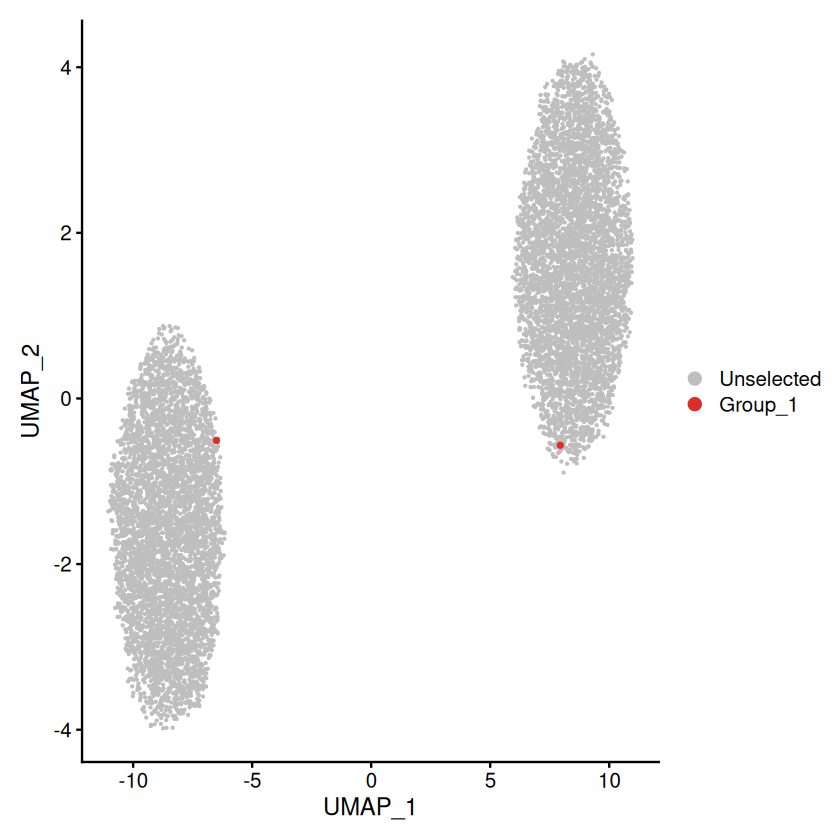

In [335]:
DimPlot(seurat_obj, reduction = "umap",  cells.highlight = c('Cell1','PCell1'),cols = c("grey", "#FF7F00")) 
# for example 
# The umap positions of the first cell in the normal group and the first cell 
# in the cancer group are as follows：

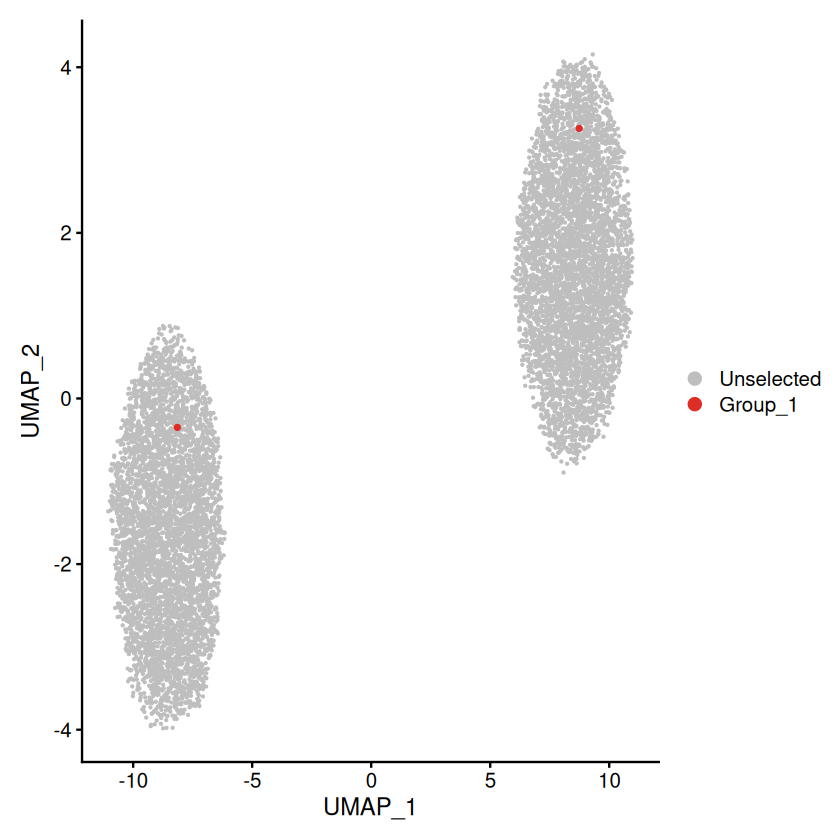

In [272]:
DimPlot(seurat_obj, reduction = "umap",  cells.highlight =  c('Cell180','PCell180'),cols = c("grey", "#FF7F00")) 


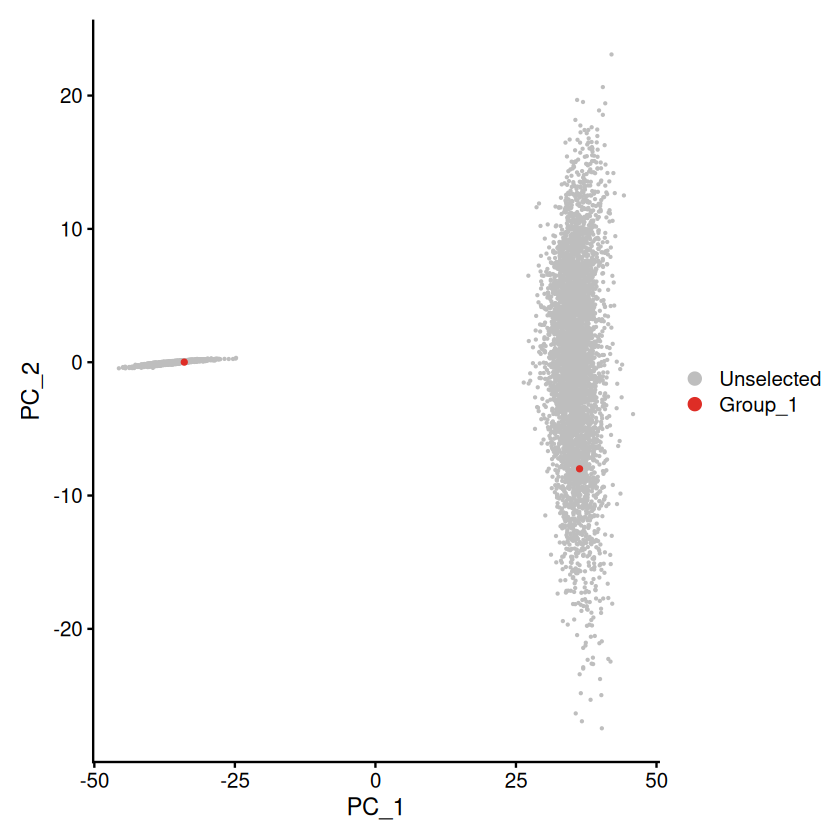

In [273]:
DimPlot(seurat_obj, reduction = "pca",  cells.highlight =  c('Cell180','PCell180'),cols = c("grey", "#FF7F00")) 


# Generate intermediate state clusters

## Sort cells according to UMAP_2

 Sort the UMAP coordinates of normal cells and cancer cells by the second dimension (UMAP_2) to obtain the sorted index order.

In [274]:
# Test the positions of the last five cells in the two groups in umap
a <- head(colnames(normal_expr_sorted))

b <- head(colnames(cancer_expr_sorted))

In [276]:
coords <- Embeddings(seurat_obj, "umap")[c(a, b), ]
print(coords)


     UMAP_1 UMAP_2


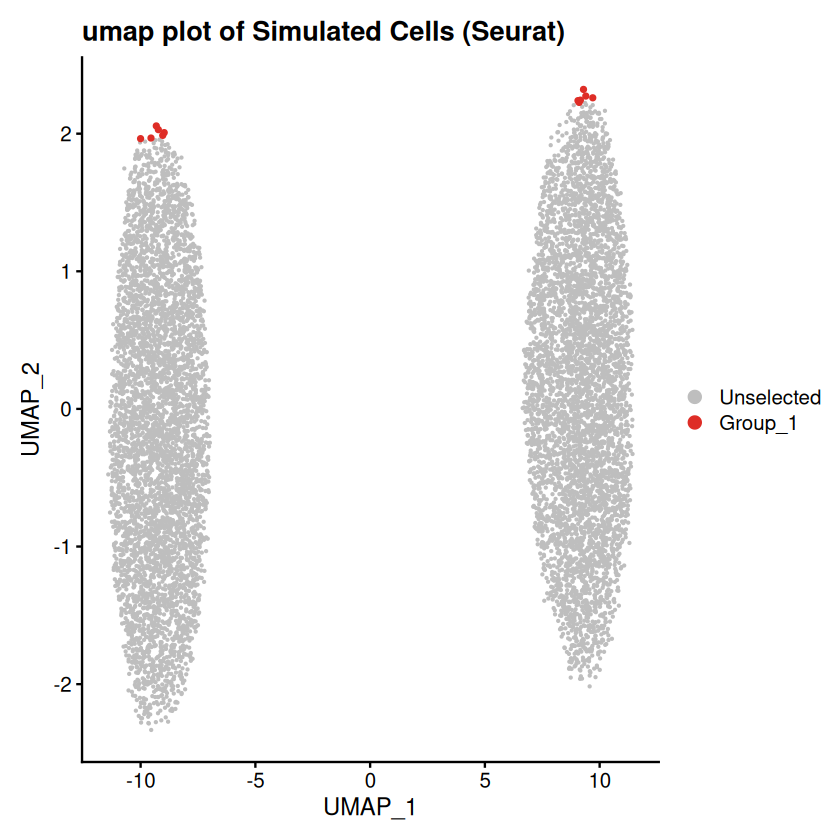

In [74]:
a <- tail(colnames(normal_expr_sorted))

b <- tail(colnames(cancer_expr_sorted))
# # Test the positions of the top five cells in the two groups in umap

DimPlot(seurat_obj, reduction = "umap",  cells.highlight = c(a,b),cols = c("grey", "#FF7F00")) +
  ggtitle("umap plot of Simulated Cells (Seurat)") 

In [829]:
# precancer_expr[1:4,1:5]

# prec_counts <- precancer_expr[paste0("Gene", seq_len(nrow(precancer_expr))),]

# colnames(prec_counts) <- paste0('TCell', seq_len(ncol(prec_counts)))

# prec_counts[1:4,1:5]

# dim(prec_counts)

# prec_counts[1:4,1:4]

# tail(seq_along(n_idx))

### Integrate the three states into a seruat object

In [341]:
library(Seurat)
stopifnot("umap" %in% Reductions(seurat_obj))

meta <- seurat_obj@meta.data
stopifnot(all(Cells(seurat_obj) == rownames(meta)))  # 关键一致性检查

umap <- Embeddings(seurat_obj, "umap")[Cells(seurat_obj), , drop = FALSE]
normal_cells <- WhichCells(seurat_obj, expression = state == "Normal")
cancer_cells <- WhichCells(seurat_obj, expression = state == "Cancer")


ord_n <- order(umap[normal_cells, "UMAP_2"])
ord_c <- order(umap[cancer_cells, "UMAP_2"])

n_idx <- normal_cells[ord_n]
c_idx <- cancer_cells[ord_c][seq_along(n_idx)]  # The two groups are of equal length; if they are not equal, take the minimum length

# Do "partial shuffling" by window (e.g. shuffle every 25 cells)
k <- 25
permute_in_blocks <- function(x, k){
  out <- x
  blocks <- split(seq_along(x), ceiling(seq_along(x)/k))
  for (b in blocks) out[b] <- sample(out[b], length(b))
  out
}
n_idx_jit <- permute_in_blocks(n_idx, k)
c_idx_jit <- permute_in_blocks(c_idx, k)


counts <- GetAssayData(seurat_obj, slot = "counts")  # dgCMatrix

normal_counts <- counts[, n_idx_jit, drop = FALSE]
cancer_counts <- counts[, c_idx_jit, drop = FALSE]

Here we used the convex combination to  convert the expression of each cell into a probability/relative expression (a non-negative vector whose sum of genes is 1) 

Why not just average the raw counts? 
Different library sizes will "skew" the average value;
The raw counts are not probability vectors on the same scale, and direct averaging is not guaranteed to be "between the two"; 

Convex combinations in probability space ensure both interpretability (mixing ratio 𝛼 α) and numerical stability (non-negative and summing to 1).

In [342]:
# Library size
Ln <- Matrix::colSums(normal_counts)
Lc <- Matrix::colSums(cancer_counts)

# Normalize to probability (add a minimum value to avoid all zero columns)
eps <- 1e-12
mun <- t( t(normal_counts) / pmax(Ln, 1) ) + eps
muc <- t( t(cancer_counts) / pmax(Lc, 1) ) + eps
# Renormalize to ensure that each column sums to 1
mun <- t( t(mun) / Matrix::colSums(mun) )
muc <- t( t(muc) / Matrix::colSums(muc) )

# α is jittered around 0.5: slowly changes with the rank of UMAP_2 + Gaussian perturbation
set.seed(1)
ranks <- seq_along(n_idx_jit)
alpha_base <- 0.5 + 0.1 * sin(2*pi*ranks/length(ranks))   #   Smooth undulations
alpha <- pmin(pmax(alpha_base + rnorm(length(ranks), 0, 0.03), 0.05), 0.95)

#Convex combination ( α_j)
combine_cols <- function(col_j, alpha_j){
  # col_j is a list( mun[,j], muc[,j] )
  alpha_j * col_j[[1]] + (1 - alpha_j) * col_j[[2]]
}
mu_prec <- do.call(cbind, lapply(seq_along(alpha), function(j){
  combine_cols(list(mun[,j], muc[,j]), alpha[j])
}))
# Normalization (numerically robust)
mu_prec <- pmax(mu_prec, eps)
mu_prec <- t( t(mu_prec) / Matrix::colSums(mu_prec) )

# Target library size: take the average of the two paired libraries and add a small jitter
Lp <- round( (Ln + Lc)/2 )
Lp <- pmax(Lp, 100)  
Lp <- round(Lp * exp(rnorm(length(Lp), 0, 0.1)))  # 10% 

# using Poisson sample
prec_cols <- lapply(seq_along(Lp), function(j){
  rpois(n = nrow(mu_prec), lambda = as.numeric(mu_prec[,j]) * Lp[j])
})
precancer_counts <- do.call(cbind, prec_cols)

In [350]:
precancer_counts[1:5,1:5]

as.matrix(seurat_obj@assays$RNA@counts)[1:4,1:3]

14,17,10,23,18
8,3,9,18,9
59,8,12,7,22
0,0,0,0,0
12,46,13,45,23


,Cell1,Cell2,Cell3
Genes1,34,34,26
Genes2,12,64,43
Genes3,33,6,52
Genes4,0,0,0


In [351]:
colnames(precancer_counts) <- paste0("PreC_", seq_len(ncol(precancer_counts)))
 rownames(precancer_counts)<- rownames(as.matrix(seurat_obj@assays$RNA@counts))
#  rownames(precancer_counts)[4001:8000 ] <- paste0('Genes',4001:8000)

precancer_counts <- Matrix::Matrix(precancer_counts, sparse = TRUE)

In [352]:
prec_seu <- CreateSeuratObject(counts = precancer_counts, 
                                 project = "PreC")

prec_seu$state <- "PreCancer"

Centering and scaling data matrix

PC_ 1 
Positive:  PGenes3147, PGenes3364, PGenes3699, PGenes243, PGenes3046, PGenes3788, PGenes1485, PGenes1710, PGenes1063, PGenes3249 
	   PGenes95, PGenes242, PGenes16, PGenes3917, PGenes1276, PGenes499, PGenes3521, PGenes3527, PGenes3269, PGenes2304 
	   PGenes1626, PGenes2294, PGenes603, PGenes2843, PGenes1484, PGenes3731, PGenes1227, PGenes3618, PGenes557, PGenes159 
Negative:  Genes1485, Genes243, Genes3046, Genes1710, Genes3917, Genes3788, Genes1276, Genes3269, Genes16, Genes3249 
	   Genes2171, Genes1484, Genes377, Genes159, Genes1007, Genes3958, Genes794, Genes1714, Genes2693, Genes595 
	   Genes914, Genes1534, Genes3574, Genes2794, Genes2643, Genes1726, Genes95, Genes406, Genes1793, Genes2229 
PC_ 2 
Positive:  Genes366, Genes544, Genes986, Genes3057, Genes2684, Genes2288, Genes1766, Genes2339, Genes3098, Genes124 
	   Genes1296, Genes291, Genes934, Genes713, Genes3586, PGenes366, Genes1325, Genes866, PGenes2023, Genes2856 
	   PGenes363, G

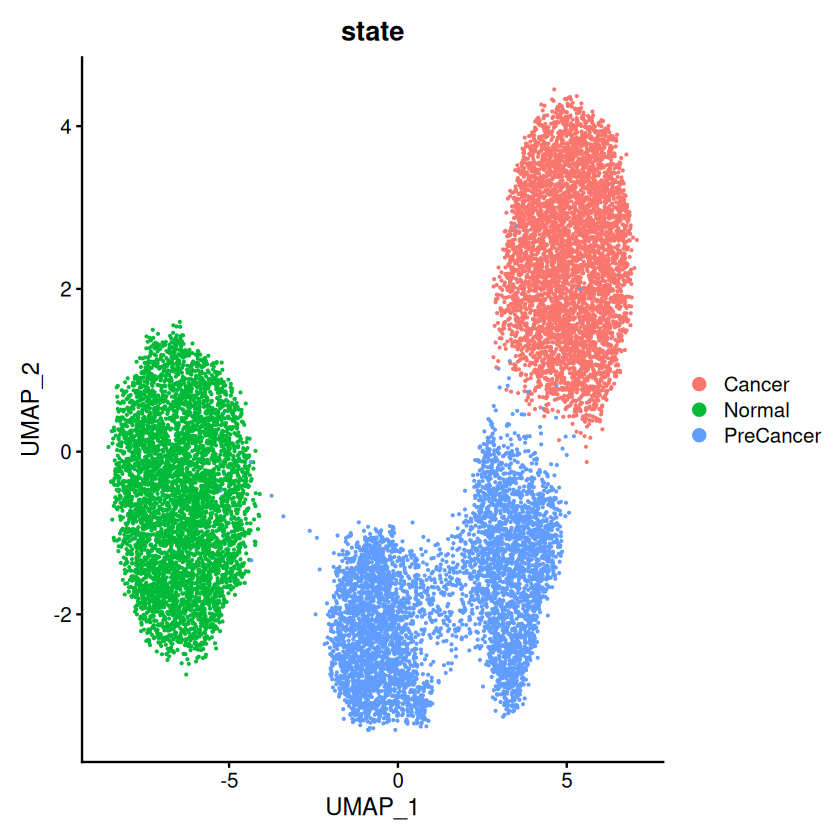

In [353]:
prec <- Matrix::cbind2(counts, precancer_counts)


meta_prec <- meta[rep(1, ncol(precancer_counts)), , drop = FALSE]
meta_prec$state <- "PreCancer"
rownames(meta_prec) <- colnames(precancer_counts)
meta_new <- rbind(meta, meta_prec)

# obj_new <- CreateSeuratObject(counts = combined_new, meta.data = meta_new)
obj_new <- merge(x = seurat_obj,y = prec_seu)

DefaultAssay(obj_new) <- "RNA"

obj_new <- NormalizeData(obj_new) |>
  FindVariableFeatures(nfeatures = 3000) |>
  ScaleData() |>
  RunPCA(npcs = 30) |>
  FindNeighbors(dims = 1:30) |>
  RunUMAP(dims = 1:30)

DimPlot(obj_new, group.by = "state", shuffle = TRUE)

An object of class Seurat 
8000 features across 15000 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

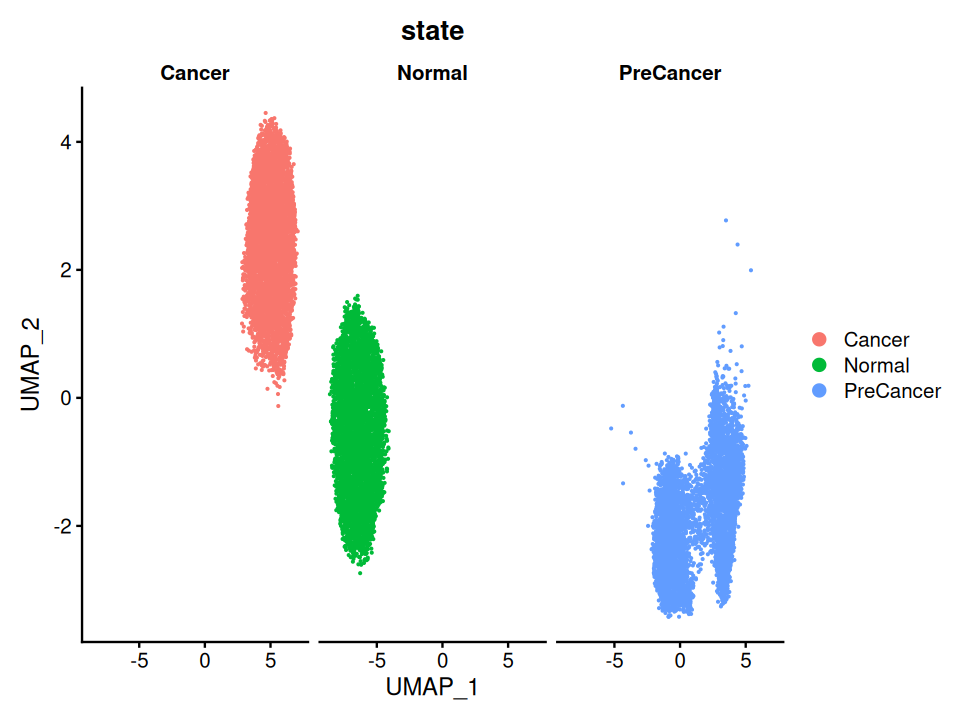

In [792]:
obj_new

options(repr.plot.width =8, repr.plot.height=6)

DimPlot(obj_new, group.by = "state", split.by = "state", shuffle = TRUE)

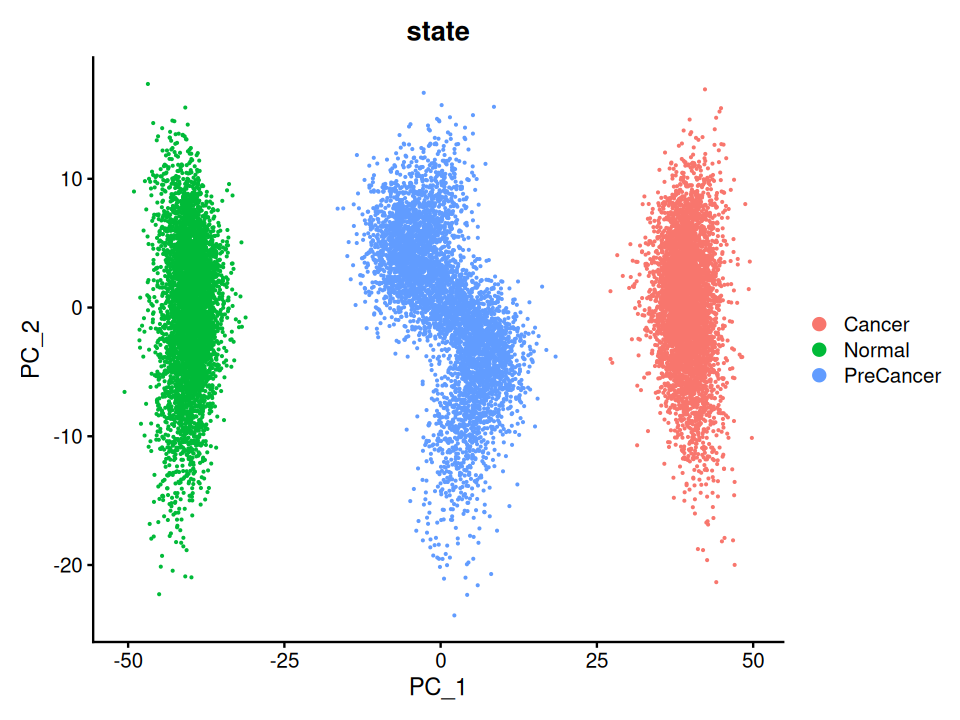

In [793]:
DimPlot(obj_new, group.by = "state", reduction = 'pca',shuffle = TRUE)


In [ ]:
obj_new

Idents(obj_new) <- 'state'

mk_CN <- FindMarkers(
  obj_new, ident.1 = "Cancer", ident.2 = "Normal",
  logfc.threshold = 2, only.pos = FALSE,
  test.use = "wilcox", verbose = FALSE
)
summary(abs(mk_CN$avg_log2FC))[c("Min.","1st Qu.","Median","Mean","3rd Qu.","Max.")]

In [835]:
head(mk_CN, 10)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Genes7,0,-3.786730,0,1.000,0
Genes15,0,-3.174432,0,1.000,0
Genes16,0,-4.241907,0,1.000,0
Genes33,0,-2.197355,0,1.000,0
Genes43,0,-2.733403,0,0.986,0
Genes47,0,-2.924758,0,1.000,0
Genes53,0,-4.208309,0,1.000,0
Genes58,0,-2.137945,0,1.000,0
Genes69,0,-2.035145,0,1.000,0


In [834]:
tail(mk_CN,10)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PGenes3891,0,2.646626,1.000,0,0
PGenes3892,0,2.751419,1.000,0,0
PGenes3900,0,2.035651,1.000,0,0
PGenes3901,0,3.414684,1.000,0,0
PGenes3917,0,3.814098,1.000,0,0
PGenes3935,0,2.317318,1.000,0,0
PGenes3937,0,6.133626,1.000,0,0
PGenes3940,0,2.156321,1.000,0,0
PGenes3946,0,4.015869,0.927,0,0


In [357]:
obj_new

counts_new <- GetAssayData(obj_new, slot = "counts") 

An object of class Seurat 
8000 features across 15000 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [363]:
# Simulating sequencing technology noise (from true counts to observed counts by using simsym)
# meta_cell data frame
meta_combined <- data.frame(State = cell_labels)

# Randomly generate gene length distribution
set.seed(789)
gene_len <- round(runif(dim(obj_new)[1], min=500, max=5000))

# Convert true counts to observed counts (adding technical noise)
observed_res <- True2ObservedCounts_parallel(
  true_counts = as.matrix(counts_new),
  meta_cell = as.data.frame(obj_new@meta.data),
  protocol = "UMI",
  alpha_mean = 0.1,
  alpha_sd = 0.002,
  gene_len = gene_len,
  depth_mean = 5e5,
  depth_sd = 1e5,
  lenslope = 0.02,
 workers = 5
)

obs_counts <- observed_res[[1]]   # Observation count matrix after adding technical noise
obs_meta <- observed_res[[2]]   #meta info


In [366]:
str(observed_res)

List of 4
 $ counts       : num [1:8000, 1:15000] 1 0 6 0 3 0 46 2 0 3 ...
 $ cell_meta    :'data.frame':	15000 obs. of  6 variables:
  ..$ orig.ident  : chr [1:15000] "SymSimData" "SymSimData" "SymSimData" "SymSimData" ...
  ..$ nCount_RNA  : num [1:15000] 372427 405854 373844 389294 418666 ...
  ..$ nFeature_RNA: int [1:15000] 3562 3549 3651 3533 3549 3440 3568 3545 3538 3638 ...
  ..$ state       : chr [1:15000] "Normal" "Normal" "Normal" "Normal" ...
  ..$ alpha       : num [1:15000] 0.1032 0.0981 0.1018 0.1004 0.1025 ...
  ..$ depth       : num [1:15000] 324681 504109 273493 551745 410892 ...
 $ nreads_perUMI:List of 15000
  ..$ 11    : int [1:38657] 12 15 41 59 10 20 6 10 10 16 ...
  ..$ 12    : int [1:39815] 0 4 22 11 71 21 15 28 48 14 ...
  ..$ 13    : int [1:38029] 2 1 28 7 6 8 25 20 9 34 ...
  ..$ 14    : int [1:38970] 2 11 10 12 0 4 34 5 35 45 ...
  ..$ 15    : int [1:42730] 2 5 47 27 19 39 15 9 7 27 ...
  ..$ 16    : int [1:35708] 1 1 113 16 10 3 17 30 2 9 ...
  ..$ 17    :

In [368]:
# Split observed_res by state; optionally convert to Seurat object
split_observed_by_state <- function(obs, to_seurat = FALSE) {
  stopifnot(is.list(obs),
            !is.null(obs$counts),
            !is.null(obs$cell_meta),
            !is.null(obs$nreads_perUMI),
            !is.null(obs$nUMI2seq))
  
  counts <- obs$counts
  meta   <- obs$cell_meta
  
  # ---- Unified cell ID (priority: counts column name > cell_meta row name > nUMI2seq name > sequential index) ----
  get_cell_ids <- function() {
    if (!is.null(colnames(counts)) && length(colnames(counts)) == ncol(counts)) {
      return(colnames(counts))
    } else if (!is.null(rownames(meta)) && nrow(meta) == ncol(counts)) {
      return(rownames(meta))
    } else if (!is.null(names(obs$nUMI2seq)) && length(names(obs$nUMI2seq)) == ncol(counts)) {
      return(names(obs$nUMI2seq))
    } else {
      return(as.character(seq_len(ncol(counts))))
    }
  }
  cell_ids <- get_cell_ids()
  colnames(counts) <- cell_ids
  rownames(meta)   <- cell_ids
  
  # nreads_perUMI / nUMI2seq Name Correction
  if (is.null(names(obs$nreads_perUMI))) names(obs$nreads_perUMI) <- cell_ids
  if (is.null(names(obs$nUMI2seq)))      names(obs$nUMI2seq)      <- cell_ids
  
  # ---- Standardized group column names ----
  if (!"state" %in% tolower(colnames(meta))) {
    stop("Unable to find grouping columns (state/group/condition etc.) in cell_meta. Please check `str(observed_res$cell_meta)`.")
  }

  state_col <- colnames(meta)[match("state", tolower(colnames(meta)))]
  meta$State <- as.character(meta[[state_col]])
  meta$State <- ifelse(tolower(meta$State) == "normal", "Normal",
                       ifelse(tolower(meta$State) == "cancer", "Cancer", meta$State))
  
  states_present <- unique(meta$State)
  states_present <- states_present[!is.na(states_present)]
  
  out <- setNames(vector("list", length(states_present)), states_present)
  
  for (s in states_present) {
    idx <- which(meta$State == s)
    ids <- cell_ids[idx]
    
    sub_counts <- counts[, ids, drop = FALSE]
    sub_meta   <- meta[ids, , drop = TRUE]
    if (is.null(dim(sub_meta))) sub_meta <- meta[ids, , drop = FALSE] 
    sub_nreads <- obs$nreads_perUMI[ids]
    sub_nUMI2  <- obs$nUMI2seq[ids]
    
    # unidy names
    colnames(sub_counts) <- ids
    rownames(sub_meta)   <- ids
    names(sub_nreads)    <- ids
    names(sub_nUMI2)     <- ids
    
    sub_obj <- list(
      counts        = sub_counts,
      cell_meta     = sub_meta,
      nreads_perUMI = sub_nreads,
      nUMI2seq      = sub_nUMI2
    )
    
    if (to_seurat) {
      # Try to use sparse matrices to save memory
      if (!inherits(sub_counts, "dgCMatrix")) {
        sub_counts <- Matrix::Matrix(as.matrix(sub_counts), sparse = TRUE)
      }
      seu <- CreateSeuratObject(counts = sub_counts, meta.data = sub_meta)
      out[[s]] <- seu
    } else {
      out[[s]] <- sub_obj
    }
  }
  
  return(out)
}


split_res <- split_observed_by_state(observed_res, to_seurat = FALSE)

# split_seu <- split_observed_by_state(observed_res, to_seurat = TRUE)

# split_seu$Normal
# split_seu$Cancer

In [592]:
# batch_res <- DivideBatches(observed_res, nbatch = 5, batch_effect_size =2)
batch_res_L <- list()
batch_res_L <- lapply(split_res,FUN = function(x){
     batch_res <- DivideBatches(x, nbatch = 6, batch_effect_size =2)
    return(batch_res)
})

In [593]:
batch_res_L[[1]][[2]][1:5,1:5]

,orig.ident,nCount_RNA,nFeature_RNA,state,alpha
,<chr>,<dbl>,<int>,<chr>,<dbl>
Cell1,SymSimData,372427,3562,Normal,0.10315674
Cell2,SymSimData,405854,3549,Normal,0.09806687
Cell3,SymSimData,373844,3651,Normal,0.10178837
Cell4,SymSimData,389294,3533,Normal,0.10035216
Cell5,SymSimData,418666,3549,Normal,0.10249702


In [594]:
seu <- list()

seu <-lapply(batch_res_L ,function(x){
    
    rownames(x[[1]]) <- rownames(as.matrix(seurat_obj@assays$RNA@counts))
    
    seurat_obj <- CreateSeuratObject(counts = x[[1]], 
                                 project = "BatchData", 
                                 meta.data = x[[2]])
    
    return(seurat_obj)
    
})


In [595]:
seurat_obj_2 <- merge(seu[[1]],seu[-1])

In [596]:
seurat_obj_2

An object of class Seurat 
8000 features across 15000 samples within 1 assay 
Active assay: RNA (8000 features, 0 variable features)
 2 layers present: counts, data

In [597]:

# batch_counts <- batch_res[[1]]   # Count matrix with batch effects
# batch_meta <- batch_res[[2]]     # meat lable 
# table(batch_meta$batch)

In [598]:
# library(Seurat)
# colnames(batch_counts) <- paste0("Cell", seq_len(ncol(batch_counts)))
# rownames(batch_counts) <- paste0("Genes", seq_len(nrow(batch_counts)))

# rownames(batch_meta) <- colnames(batch_counts)

# seurat_obj <- CreateSeuratObject(counts = batch_counts, 
#                                  project = "SymSimData", 
#                                  meta.data = batch_meta)
# seurat_obj


seurat_obj_2 <- NormalizeData(seurat_obj_2)  %>%

 FindVariableFeatures(selection.method = "vst", nfeatures = 3000 )  

top10 <- head( VariableFeatures(seurat_obj_2), 10 )
print(top10)

seurat_obj_2 <- ScaleData(seurat_obj_2)

 [1] "Genes2218"  "PGenes2218" "PGenes1234" "PGenes1229" "PGenes2240"
 [6] "PGenes523"  "PGenes1319" "Genes2974"  "PGenes769"  "Genes2240" 


Centering and scaling data matrix



In [599]:
k =30
seurat_obj_2 <- RunPCA(seurat_obj_2, npcs = k,verbose = FALSE)  
seurat_obj_2 <- FindNeighbors(seurat_obj_2, dims = 1:k)%>%
 FindClusters()  %>%

 RunUMAP( dims = 1:k) %>% RunTSNE( dims = 1:k)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 562416

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9554
Number of communities: 18
Elapsed time: 1 seconds


12:53:08 UMAP embedding parameters a = 0.9922 b = 1.112

12:53:08 Read 15000 rows and found 30 numeric columns

12:53:08 Using Annoy for neighbor search, n_neighbors = 30

12:53:08 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:53:08 Writing NN index file to temp file /tmp/Rtmp01mvJq/filebb53bd45776d

12:53:08 Searching Annoy index using 1 thread, search_k = 3000

12:53:11 Annoy recall = 100%

12:53:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:53:14 Found 18 connected components, 
falling back to 'spca' initialization with init_sdev = 1

12:53:14 Using 'irlba' for PCA

12:53:14 PCA: 2 components explained 60.78% variance

12:53:14 Scaling init to sdev = 1

12:53:14 Commencing optimization for 200 epochs, with 607734

In [600]:
table(seurat_obj_2$State)


   Cancer    Normal PreCancer 
     5000      5000      5000 

In [601]:
seurat_obj_2$new_batch <- paste0(seurat_obj_2$State,'_',seurat_obj_2$batch)

head(seurat_obj_2@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,state,alpha,depth,State,batch,RNA_snn_res.0.8,seurat_clusters,new_batch
,<chr>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<chr>,<int>,<fct>,<fct>,<chr>
Cell1,SymSimData,372427,3562,Normal,0.10315674,324680.6,Normal,3,8,8,Normal_3
Cell2,SymSimData,405854,3549,Normal,0.09806687,504109.0,Normal,3,8,8,Normal_3
Cell3,SymSimData,373844,3651,Normal,0.10178837,273492.9,Normal,5,10,10,Normal_5
Cell4,SymSimData,389294,3533,Normal,0.10035216,551745.4,Normal,4,1,1,Normal_4
Cell5,SymSimData,418666,3549,Normal,0.10249702,410892.1,Normal,6,11,11,Normal_6
Cell6,SymSimData,361312,3440,Normal,0.09948574,709114.0,Normal,4,1,1,Normal_4


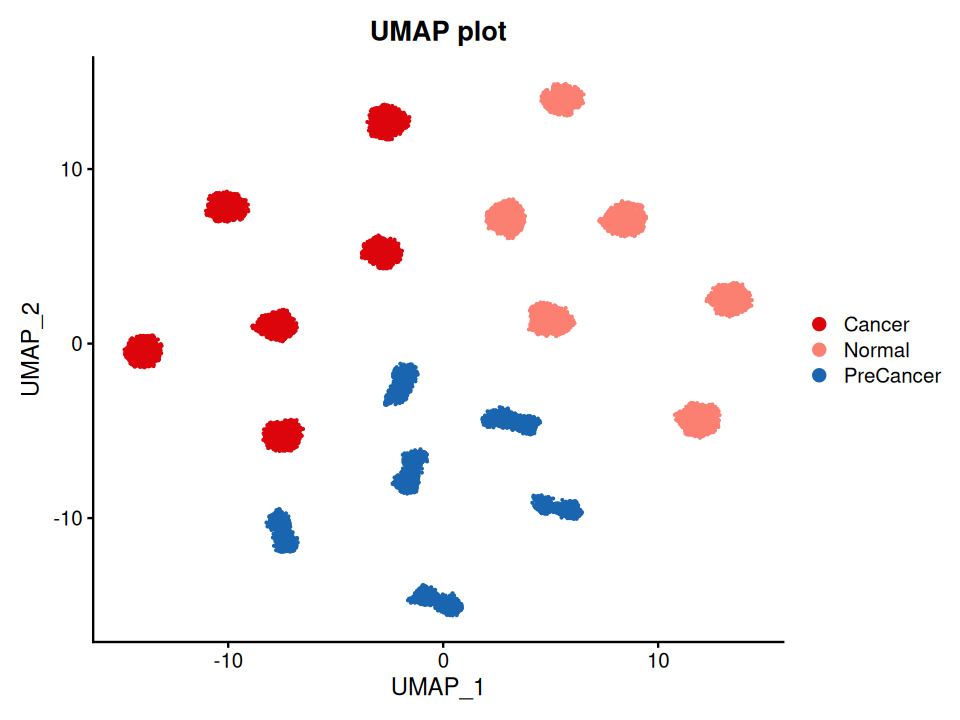

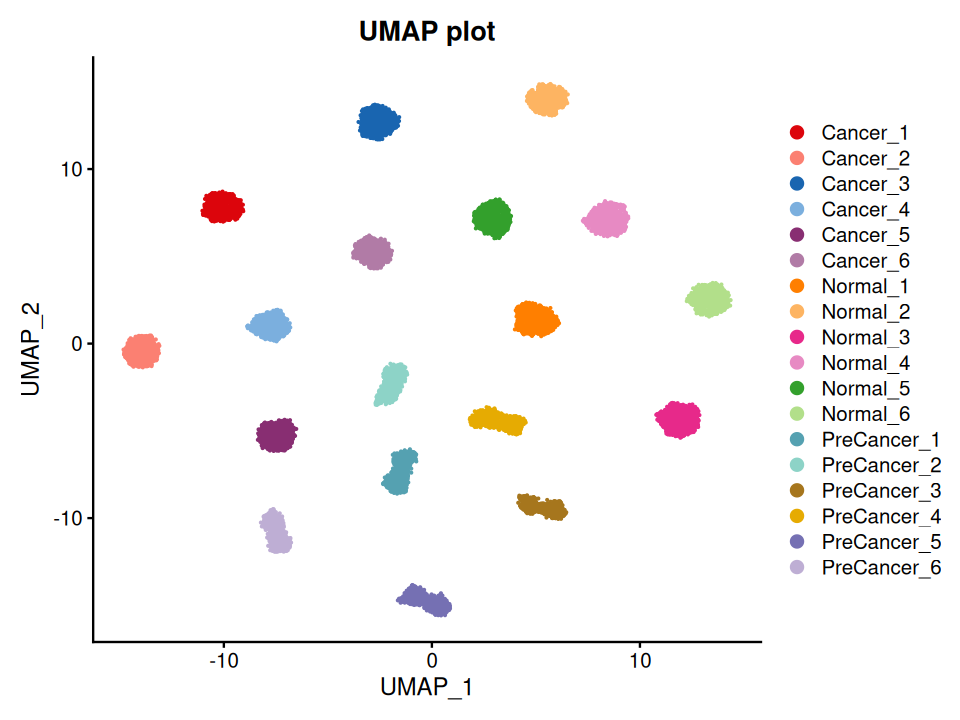

In [602]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj_2, reduction = "umap", group.by = "State" ,cols = cluster_cols) + ggtitle('UMAP plot')
DimPlot(seurat_obj_2, reduction = "umap", group.by = "new_batch",cols = cluster_cols) + ggtitle('UMAP plot')
# DimPlot(seurat_obj, reduction = "umap", label = TRUE,cols = cluster_cols)  

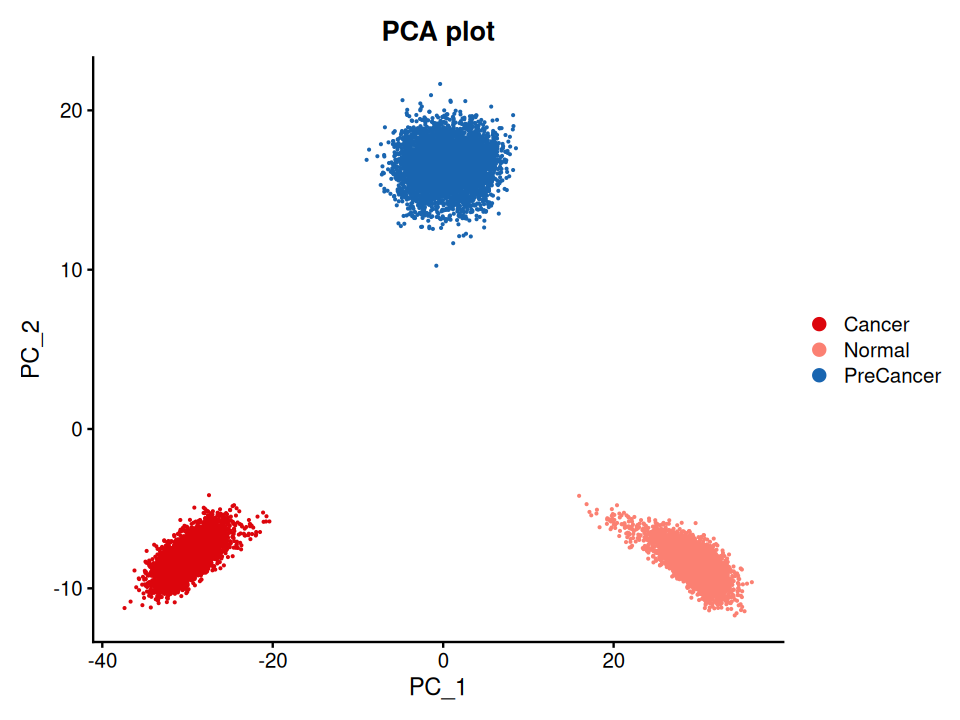

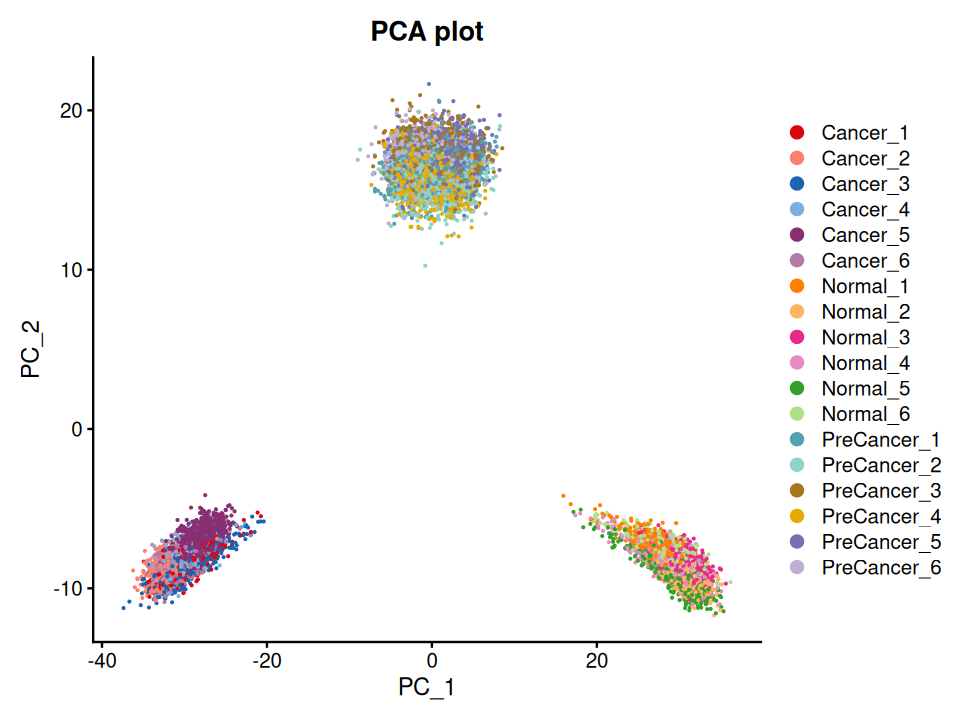

In [603]:
DimPlot(seurat_obj_2, reduction = "pca", group.by = "State" ,cols = cluster_cols) + ggtitle('PCA plot')
DimPlot(seurat_obj_2, reduction = "pca", group.by = "new_batch",cols = cluster_cols) + ggtitle('PCA plot')


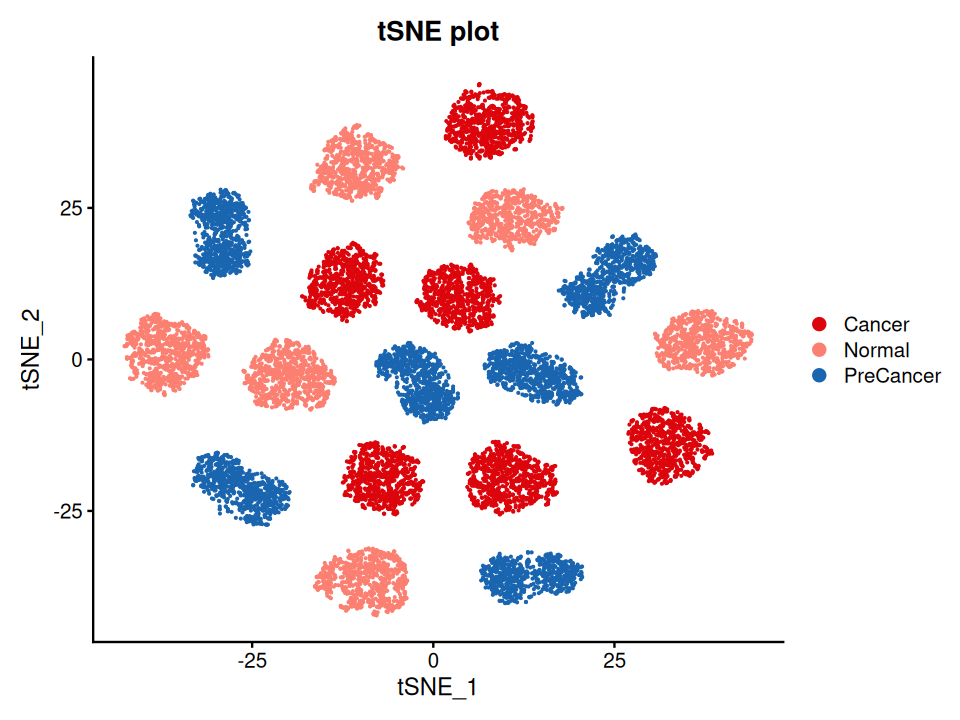

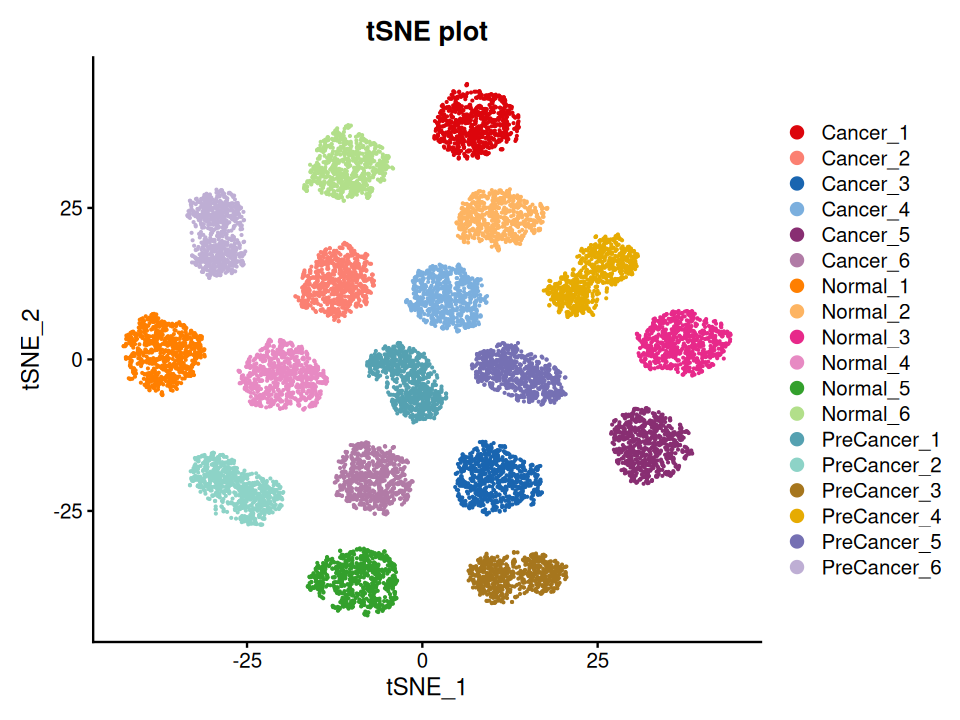

In [604]:
DimPlot(seurat_obj_2, reduction = "tsne", group.by = "State" ,cols = cluster_cols) + ggtitle('tSNE plot')
DimPlot(seurat_obj_2, reduction = "tsne", group.by = "new_batch",cols = cluster_cols) + ggtitle('tSNE plot')


In [605]:
seurat_obj_2 <-RunHarmony(seurat_obj_2,group.by.vars = 'new_batch')

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations



In [606]:
seurat_obj_2 <- FindNeighbors(seurat_obj_2, dims = 1:k,reduction = 'harmony')%>%
 FindClusters()  %>%

 RunUMAP( dims = 1:k,reduction = 'harmony') %>% RunTSNE( dims = 1:k,reduction = 'harmony')

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 443199

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7664
Number of communities: 6
Elapsed time: 1 seconds


12:54:11 UMAP embedding parameters a = 0.9922 b = 1.112

12:54:11 Read 15000 rows and found 30 numeric columns

12:54:11 Using Annoy for neighbor search, n_neighbors = 30

12:54:11 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:54:11 Writing NN index file to temp file /tmp/Rtmp01mvJq/filebb53b46601112

12:54:11 Searching Annoy index using 1 thread, search_k = 3000

12:54:14 Annoy recall = 100%

12:54:15 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:54:17 Found 3 connected components, 
falling back to 'spca' initialization with init_sdev = 1

12:54:17 Using 'irlba' for PCA

12:54:17 PCA: 2 components explained 85.45% variance

12:54:17 Scaling init to sdev = 1

12:54:17 Commencing optimization for 200 epochs, with 622400

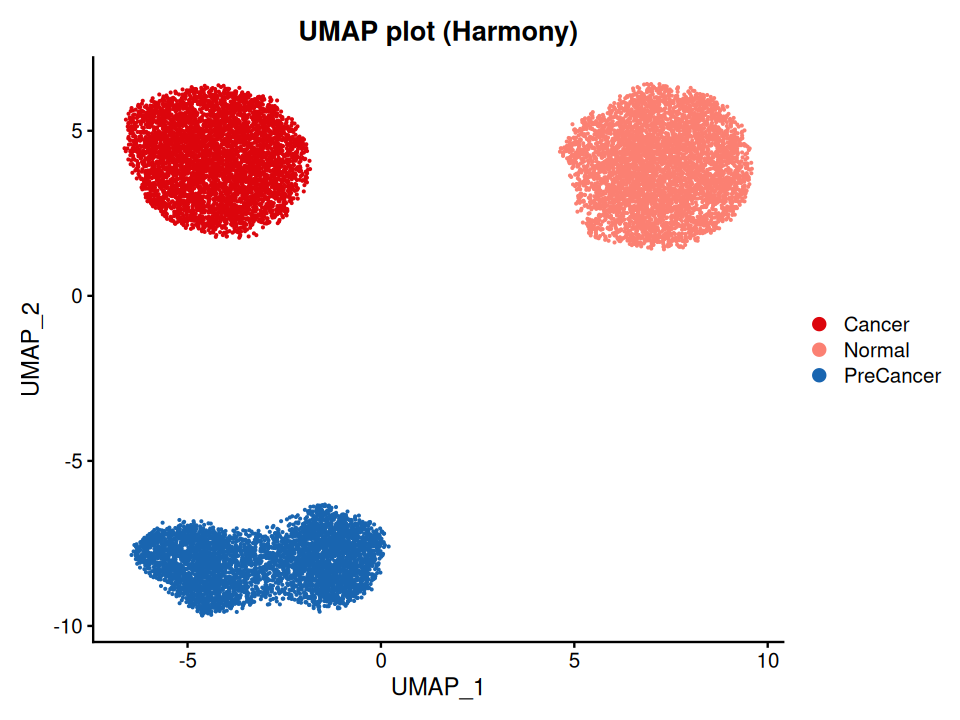

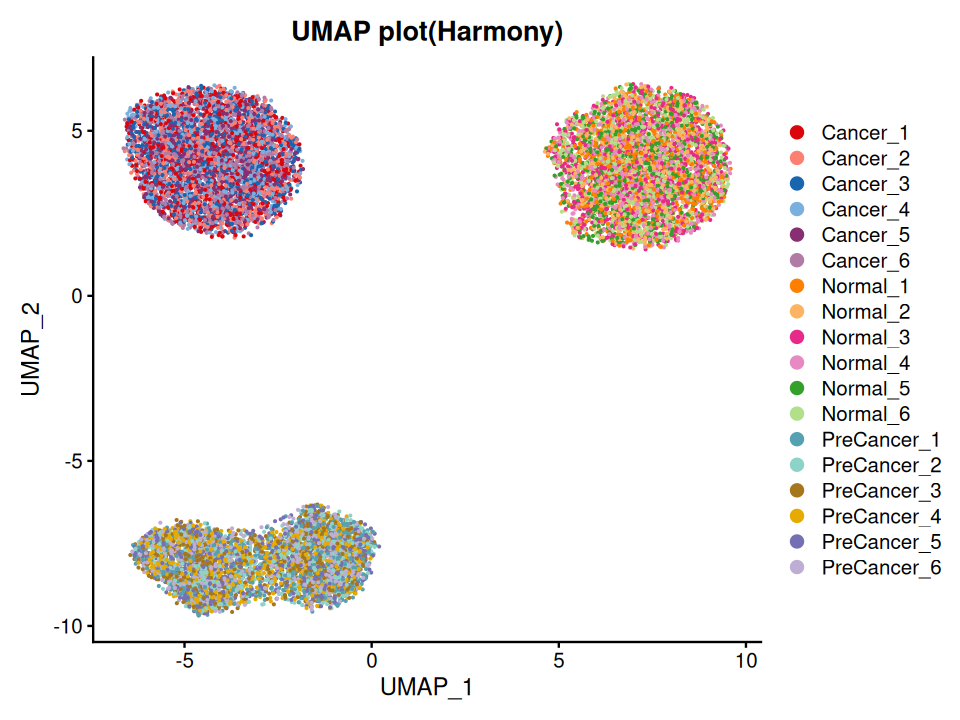

In [607]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(seurat_obj_2, reduction = "umap", group.by = "State" ,cols = cluster_cols) + ggtitle('UMAP plot (Harmony)')
DimPlot(seurat_obj_2, reduction = "umap", group.by = "new_batch",cols = cluster_cols) + ggtitle('UMAP plot(Harmony)')
# DimPlot(seurat_obj, reduction = "umap", label = TRUE,cols = cluster_cols)  

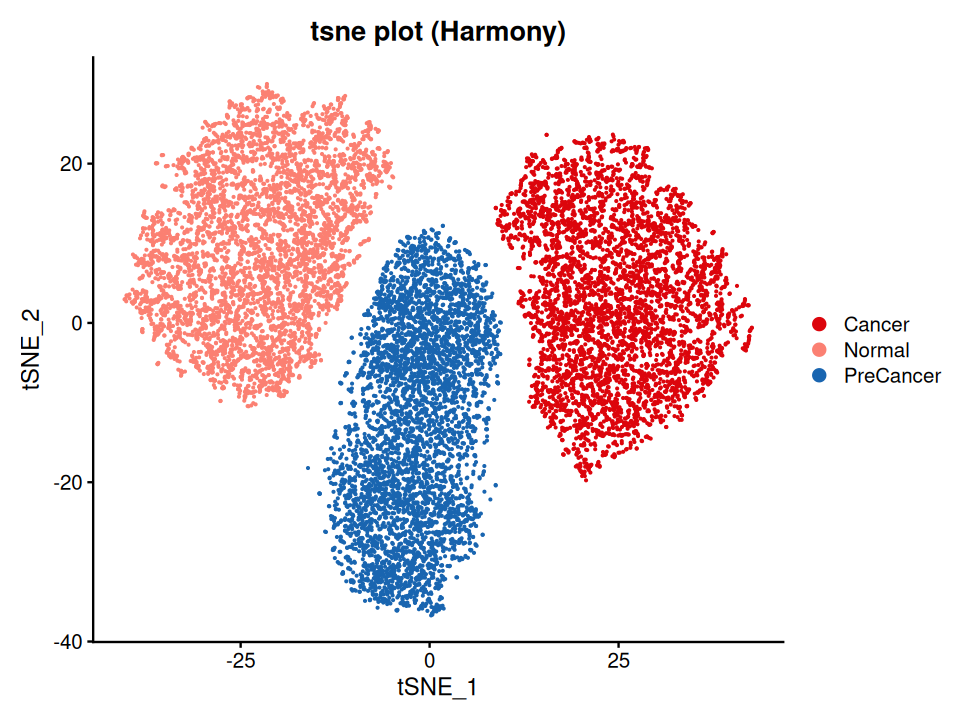

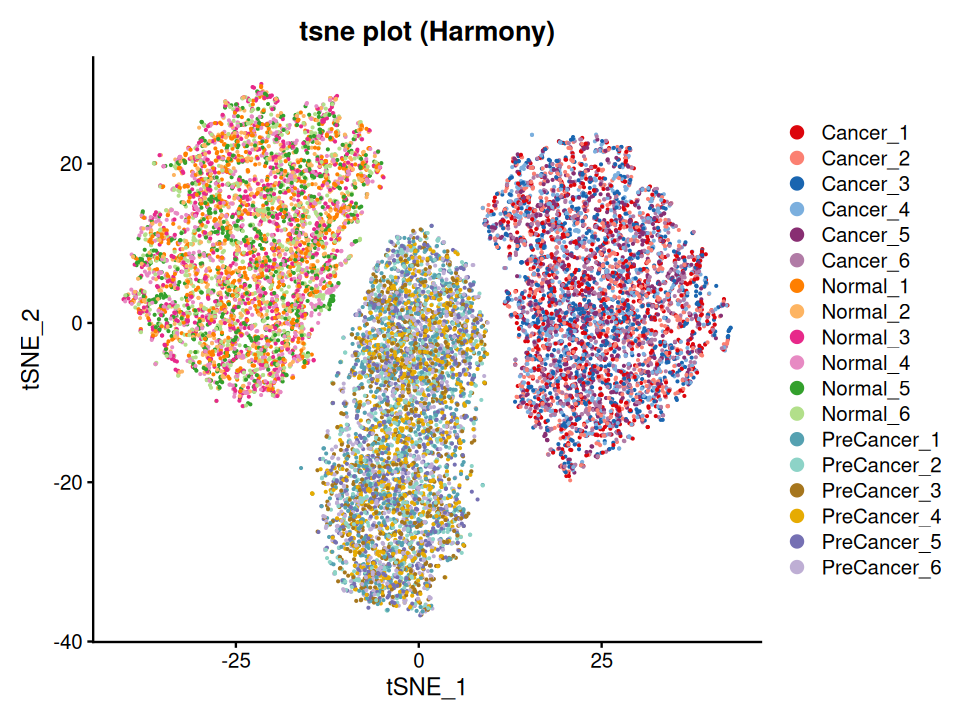

In [608]:
DimPlot(seurat_obj_2, reduction = "tsne", group.by = "State" ,cols = cluster_cols) + ggtitle('tsne plot (Harmony)')
DimPlot(seurat_obj_2, reduction = "tsne", group.by = "new_batch",cols = cluster_cols) + ggtitle('tsne plot (Harmony)' )


In [609]:
Idents(seurat_obj_2) <- 'new_batch'

split_list <- SplitObject(seurat_obj_2,split.by = 'new_batch' )

split_list

$Normal_3
An object of class Seurat 
8000 features across 836 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, umap, tsne, harmony

$Normal_5
An object of class Seurat 
8000 features across 832 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, umap, tsne, harmony

$Normal_4
An object of class Seurat 
8000 features across 879 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, umap, tsne, harmony

$Normal_6
An object of class Seurat 
8000 features across 820 samples within 1 assay 
Active assay: RNA (8000 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, umap, tsne, h

In [610]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


In [611]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
   Genes1   Genes10 Genes1000 Genes1001 Genes1002 Genes1004 
        3         6        10         6         8         9 

In [797]:
hvg_freq_df[3000,]

,gene,frequency
,<chr>,<int>
1548,Genes2525,8


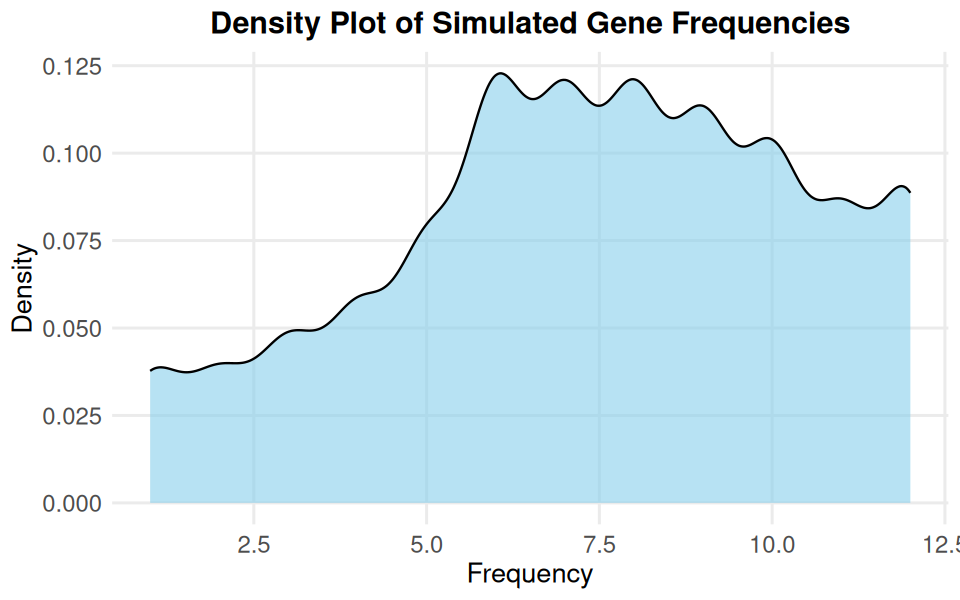

In [612]:
options(repr.plot.width =8, repr.plot.height=5)

ggplot(hvg_freq_df, aes(x = frequency)) +
  geom_density(fill = "skyblue", alpha = 0.6) +
  theme_minimal(base_size = 14) +  
  labs(
    title = "Density Plot of Simulated Gene Frequencies",
    x = "Frequency",
    y = "Density"
  ) +
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),  
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    panel.grid.minor = element_blank() 
  )


In [613]:
HVGs <- head(hvg_freq_df$gene,3000)

dir <- "/mnt/fast00/Minghui/Simulate_data_20Aug/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  data[data < 0] <- 0
  
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_5/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_6/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Normal_2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Cancer_4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Cancer_1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Cancer_2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Cancer_5/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data_20Aug//Cancer_3/scaled_matrix.txt

Scaled mat

In [759]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 20, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                          Normal_3 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_3_k20_theta03_W.csv" 
                                                                          Normal_5 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_5_k20_theta03_W.csv" 
                                                                          Normal_4 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_4_k20_theta03_W.csv" 
                                                                          Normal_6 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_6_k20_theta03_W.csv" 
                                                                          Normal_1 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_1_k20_theta03_W.csv" 
                                                                          Normal_2 
   "/mnt/fast00/Minghui/Simulate_data_20Aug/output_csv/Normal_2_k20_theta03_

In [760]:
head(HVGs)

[1] "Genes1006" "Genes1010" "Genes1011" "Genes102"  "Genes1030" "Genes1056"

In [761]:
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

names(w_list) <- names(target_files)

print(names(w_list))

gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

#
names(w_list) <- names(target_files)

head(w_list[[1]])

 [1] "Normal_3"    "Normal_5"    "Normal_4"    "Normal_6"    "Normal_1"   
 [6] "Normal_2"    "Cancer_4"    "Cancer_1"    "Cancer_2"    "Cancer_5"   
[11] "Cancer_3"    "Cancer_6"    "PreCancer_6" "PreCancer_4" "PreCancer_3"
[16] "PreCancer_5" "PreCancer_1" "PreCancer_2"


,Normal_3_Program_1,Normal_3_Program_2,Normal_3_Program_3,Normal_3_Program_4,Normal_3_Program_5,Normal_3_Program_6,Normal_3_Program_7,Normal_3_Program_8,Normal_3_Program_9,Normal_3_Program_10,Normal_3_Program_11,Normal_3_Program_12,Normal_3_Program_13,Normal_3_Program_14,Normal_3_Program_15,Normal_3_Program_16,Normal_3_Program_17,Normal_3_Program_18,Normal_3_Program_19,Normal_3_Program_20
Genes1006,1.106920e-07,0.49237770,0.00000001,0.00000001,0.000000010,1.747321e-01,0.23137702,0.105632313,0.04119263,0.02642925,0.00000001,0.00000001,0.043657888,0.000000010,0.046725195,0.15656146,0.06746954,0.00000001,0.05694392,0.002270706
Genes1010,1.000000e-08,0.00000001,0.01148053,0.14573672,0.000000010,1.000000e-08,0.08173230,0.000000010,0.01558500,0.00000001,0.00000001,0.00000001,0.000000010,0.000000010,0.000000010,0.02337179,0.03494218,0.31846678,0.00000001,0.000000010
Genes1011,1.000000e-08,0.20047958,0.23676005,0.05201033,0.005728089,1.018796e-08,0.00000001,0.001694314,0.03236491,0.03524921,0.00000001,0.09236987,0.006537493,0.000000010,0.000147011,0.09231175,0.09992435,0.18183608,0.32649103,0.085906327
Genes102,1.000000e-08,0.00000001,0.03309235,0.10269605,0.013111249,2.106948e-01,0.04096642,0.000000010,0.00000001,0.03744283,0.00000001,0.12445403,0.054402538,0.000000010,0.269528300,0.00000001,0.00000001,0.00000001,0.15560402,0.144331068
Genes1030,1.000000e-08,0.11575187,0.00000001,0.14175592,0.356216282,1.677888e-01,0.00000001,0.000000010,0.00000001,0.00000001,0.17701973,0.00000001,0.000000010,0.000000010,0.000000010,0.01500091,0.00000001,0.00000001,0.00000001,0.000000010
Genes1056,1.505074e-01,0.33221659,0.10086025,0.02087438,0.070794106,1.279465e-01,0.02039472,0.053897601,0.07574055,0.11598934,0.02090594,0.02374713,0.092063665,0.009517359,0.154371709,0.13895299,0.15492903,0.04439969,0.12802826,0.037399963


In [762]:
merge_matrix <- do.call(cbind ,w_list)
head(merge_matrix)

,Normal_3_Program_1,Normal_3_Program_2,Normal_3_Program_3,Normal_3_Program_4,Normal_3_Program_5,Normal_3_Program_6,Normal_3_Program_7,Normal_3_Program_8,Normal_3_Program_9,Normal_3_Program_10,⋯,PreCancer_2_Program_11,PreCancer_2_Program_12,PreCancer_2_Program_13,PreCancer_2_Program_14,PreCancer_2_Program_15,PreCancer_2_Program_16,PreCancer_2_Program_17,PreCancer_2_Program_18,PreCancer_2_Program_19,PreCancer_2_Program_20
Genes1006,1.106920e-07,0.49237770,0.00000001,0.00000001,0.000000010,1.747321e-01,0.23137702,0.105632313,0.04119263,0.02642925,⋯,0.09304913,0.08981792,2.615696e-05,0.08761206,2.025199e-03,0.000000010,0.37160364,0.05671623,3.903197e-07,0.0004001602
Genes1010,1.000000e-08,0.00000001,0.01148053,0.14573672,0.000000010,1.000000e-08,0.08173230,0.000000010,0.01558500,0.00000001,⋯,0.05273324,0.00000001,2.688756e-03,0.00000001,5.505858e-06,0.014972265,0.14283663,0.04579130,1.000000e-08,0.2702896893
Genes1011,1.000000e-08,0.20047958,0.23676005,0.05201033,0.005728089,1.018796e-08,0.00000001,0.001694314,0.03236491,0.03524921,⋯,0.07920812,0.05291583,1.000000e-08,0.08361617,2.927861e-04,0.004250234,0.00000001,0.17052056,1.074982e-08,0.3212128878
Genes102,1.000000e-08,0.00000001,0.03309235,0.10269605,0.013111249,2.106948e-01,0.04096642,0.000000010,0.00000001,0.03744283,⋯,0.12485064,0.05347145,1.000000e-08,0.14262226,1.000000e-08,0.000000010,0.00000001,0.07689389,1.105049e-01,0.0000000100
Genes1030,1.000000e-08,0.11575187,0.00000001,0.14175592,0.356216282,1.677888e-01,0.00000001,0.000000010,0.00000001,0.00000001,⋯,0.25914454,0.01039480,1.475584e-01,0.00000001,4.305767e-02,0.150834337,0.00000001,0.06116177,5.058855e-02,0.0807308555
Genes1056,1.505074e-01,0.33221659,0.10086025,0.02087438,0.070794106,1.279465e-01,0.02039472,0.053897601,0.07574055,0.11598934,⋯,0.13849632,0.05208914,1.369466e-02,0.09621890,1.011323e-01,0.021579074,0.06641709,0.15127739,1.062439e-01,0.0975319445


In [763]:
mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns

,Normal_3_Program_1,Normal_3_Program_2,Normal_3_Program_3,Normal_3_Program_4,Normal_3_Program_5,Normal_3_Program_6,Normal_3_Program_7,Normal_3_Program_8,Normal_3_Program_9,Normal_3_Program_10,⋯,PreCancer_2_Program_11,PreCancer_2_Program_12,PreCancer_2_Program_13,PreCancer_2_Program_14,PreCancer_2_Program_15,PreCancer_2_Program_16,PreCancer_2_Program_17,PreCancer_2_Program_18,PreCancer_2_Program_19,PreCancer_2_Program_20
Genes1006,2.516770e-08,9.854319e-02,2.150998e-09,2.738482e-09,2.819581e-09,3.770458e-02,5.441217e-02,2.556651e-02,9.228951e-03,5.768862e-03,⋯,0.01841922,1.591996e-02,4.652566e-06,1.667732e-02,3.264884e-04,1.937298e-09,7.049937e-02,0.011867558,9.022216e-08,7.867401e-05
Genes1010,2.273669e-09,2.001374e-09,2.469460e-03,3.990973e-02,2.819581e-09,2.157850e-09,1.922072e-02,2.420331e-09,3.491721e-03,2.182757e-09,⋯,0.01043863,1.772470e-09,4.782519e-04,1.903542e-09,8.876157e-07,2.900574e-03,2.709848e-02,0.009581577,2.311494e-09,5.314064e-02
Genes1011,2.273669e-09,4.012346e-02,5.092704e-02,1.424293e-02,1.615081e-03,2.198409e-09,2.351667e-09,4.100801e-04,7.251155e-03,7.694045e-03,⋯,0.01567937,9.379175e-03,1.778710e-09,1.591669e-02,4.720091e-05,8.233971e-04,1.897166e-09,0.035680489,2.484814e-09,6.315246e-02
Genes102,2.273669e-09,2.001374e-09,7.118157e-03,2.812313e-02,3.696822e-03,4.546479e-02,9.633939e-03,2.420331e-09,2.240437e-09,8.172858e-03,⋯,0.02471438,9.477656e-03,1.778710e-09,2.714874e-02,1.612130e-09,1.937298e-09,1.897166e-09,0.016089623,2.554315e-02,1.966063e-09
Genes1030,2.273669e-09,2.316628e-02,2.150998e-09,3.881960e-02,1.004381e-01,3.620632e-02,2.351667e-09,2.420331e-09,2.240437e-09,2.182757e-09,⋯,0.05129807,1.842448e-03,2.624636e-02,1.903542e-09,6.941455e-03,2.922111e-02,1.897166e-09,0.012797764,1.169351e-02,1.587219e-02
Genes1056,3.422039e-02,6.648896e-02,2.169502e-02,5.716410e-03,1.996097e-02,2.760893e-02,4.796160e-03,1.304500e-02,1.696919e-02,2.531765e-02,⋯,0.02741556,9.232646e-03,2.435883e-03,1.831567e-02,1.630384e-02,4.180510e-03,1.260042e-02,0.031653963,2.455822e-02,1.917539e-02


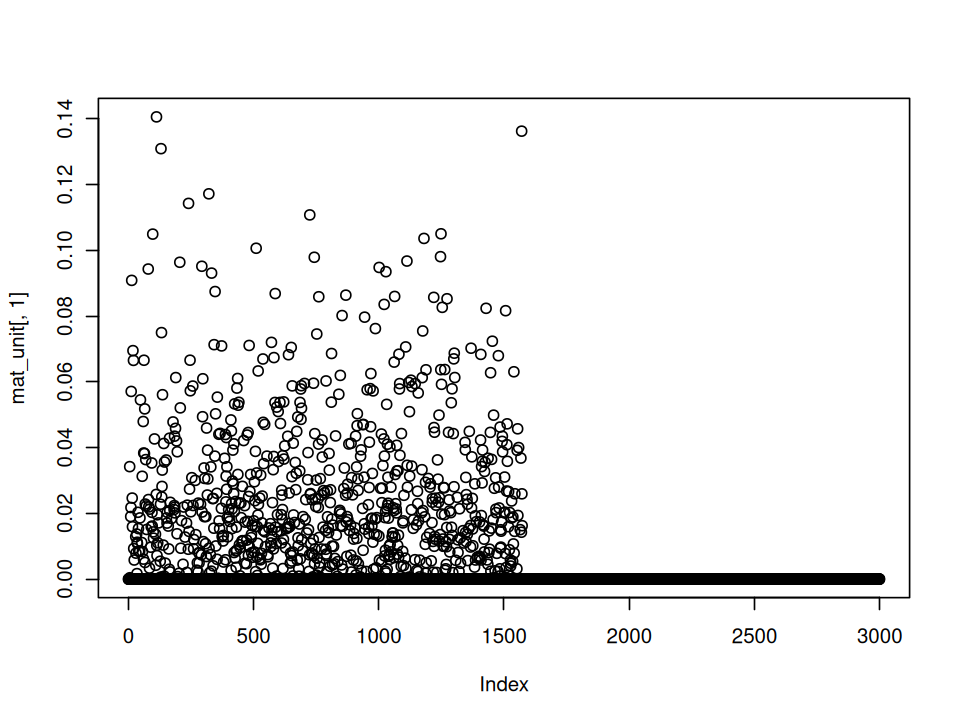

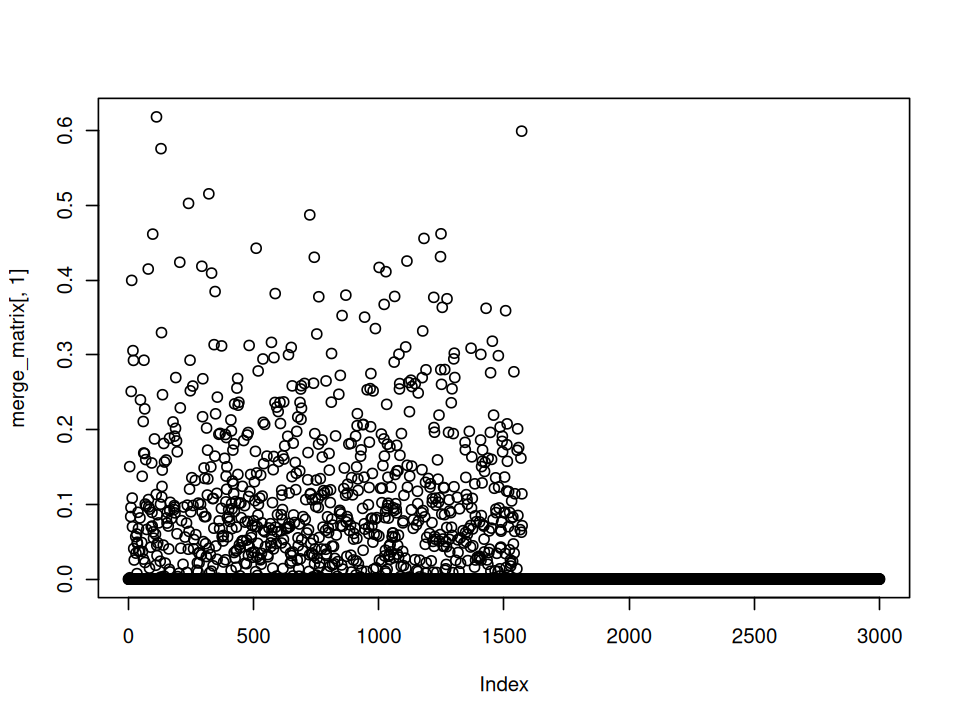

In [764]:
options(repr.plot.width =8, repr.plot.height=6)
#Density plot =
head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])


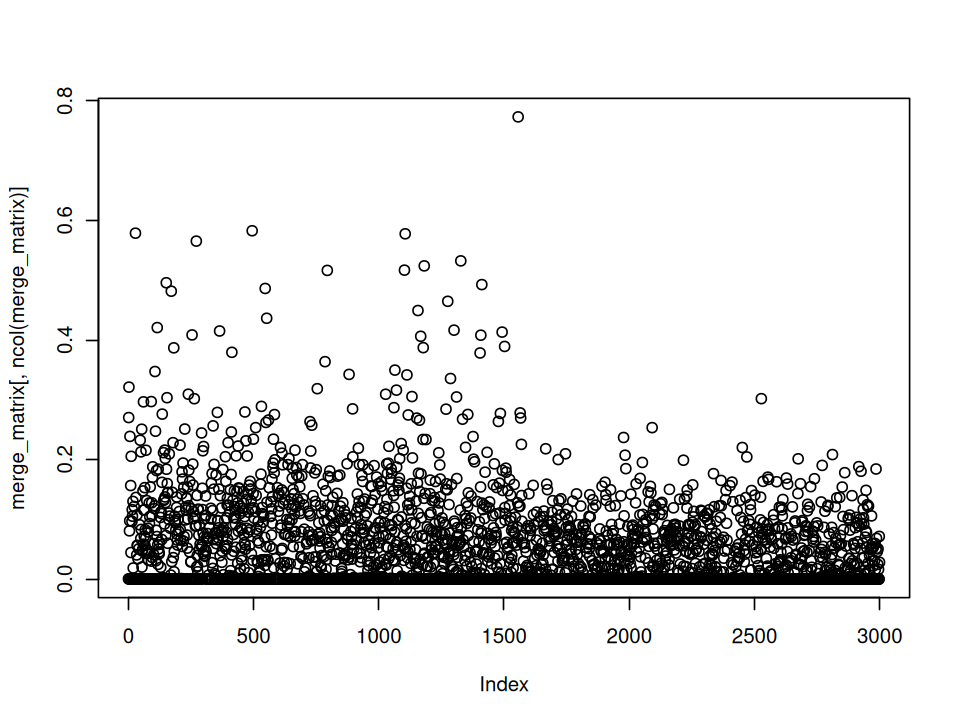

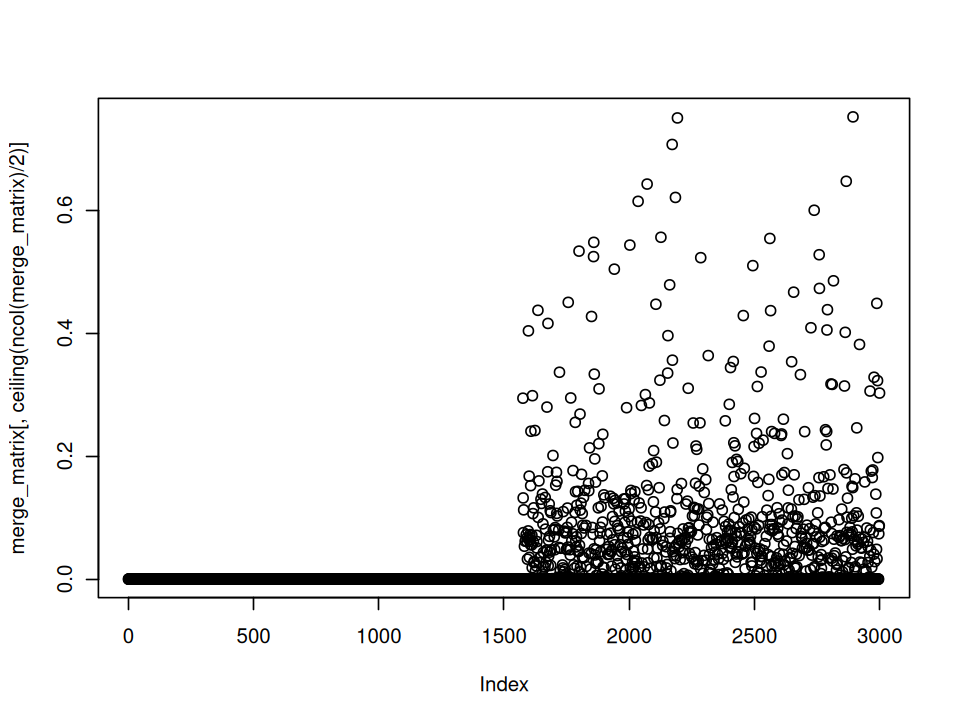

In [838]:
options(repr.plot.width =8, repr.plot.height=6)

plot(merge_matrix[,ncol(merge_matrix)])

plot(merge_matrix[,ceiling(ncol(merge_matrix)/2)])


[1] 0.6319296 0.6513974 0.6135142 0.6629511 0.7033619 0.7409361

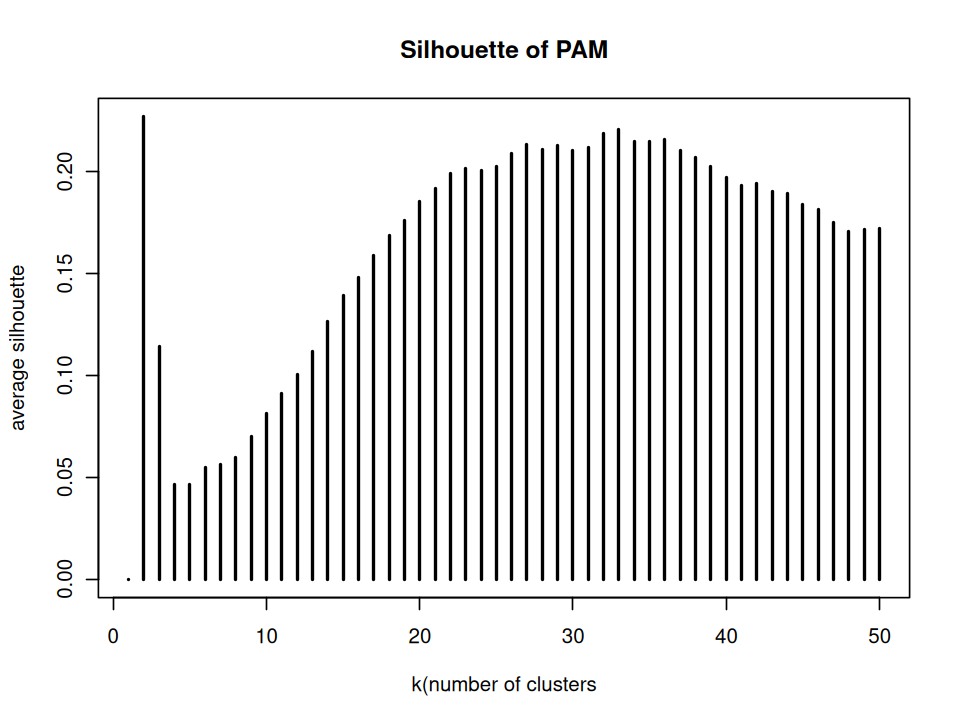

In [765]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

asw <- numeric(50)
for (i in 2:50) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

In [777]:
which.max(asw[-2])

[1] 32

In [778]:
# k = k.best
k = which.max(asw[-2])+1

pam_data <- pam(t(mat_unit),k , diss = TRUE)

Warning message in as.dist.default(x):
“non-square matrix”


In [779]:
pam_data$medoids

[1] "PreCancer_1_Program_11" "PreCancer_2_Program_10" "PreCancer_6_Program_17"
 [4] "Cancer_3_Program_5"     "PreCancer_2_Program_15" "PreCancer_5_Program_2" 
 [7] "PreCancer_1_Program_3"  "PreCancer_3_Program_1"  "PreCancer_4_Program_10"
[10] "Cancer_6_Program_7"     "Cancer_6_Program_10"    "PreCancer_6_Program_5" 
[13] "PreCancer_4_Program_20" "PreCancer_1_Program_15" "PreCancer_3_Program_15"
[16] "PreCancer_5_Program_4"  "PreCancer_5_Program_6"  "PreCancer_5_Program_10"
[19] "PreCancer_2_Program_2"  "PreCancer_5_Program_16" "PreCancer_5_Program_17"
[22] "PreCancer_1_Program_1"  "PreCancer_1_Program_7"  "PreCancer_1_Program_12"
[25] "PreCancer_1_Program_17" "PreCancer_1_Program_19" "PreCancer_1_Program_20"
[28] "PreCancer_2_Program_14" "PreCancer_2_Program_16" "PreCancer_2_Program_17"
[31] "PreCancer_2_Program_18" "PreCancer_2_Program_19" "PreCancer_2_Program_20"

In [780]:
medoid_names <- pam_data$medoids

medoid_vectors <- mat_unit[, pam_data$medoids]



In [781]:
medoid_names

names(w_list)

[1] "PreCancer_1_Program_11" "PreCancer_2_Program_10" "PreCancer_6_Program_17"
 [4] "Cancer_3_Program_5"     "PreCancer_2_Program_15" "PreCancer_5_Program_2" 
 [7] "PreCancer_1_Program_3"  "PreCancer_3_Program_1"  "PreCancer_4_Program_10"
[10] "Cancer_6_Program_7"     "Cancer_6_Program_10"    "PreCancer_6_Program_5" 
[13] "PreCancer_4_Program_20" "PreCancer_1_Program_15" "PreCancer_3_Program_15"
[16] "PreCancer_5_Program_4"  "PreCancer_5_Program_6"  "PreCancer_5_Program_10"
[19] "PreCancer_2_Program_2"  "PreCancer_5_Program_16" "PreCancer_5_Program_17"
[22] "PreCancer_1_Program_1"  "PreCancer_1_Program_7"  "PreCancer_1_Program_12"
[25] "PreCancer_1_Program_17" "PreCancer_1_Program_19" "PreCancer_1_Program_20"
[28] "PreCancer_2_Program_14" "PreCancer_2_Program_16" "PreCancer_2_Program_17"
[31] "PreCancer_2_Program_18" "PreCancer_2_Program_19" "PreCancer_2_Program_20"

[1] "Normal_3"    "Normal_5"    "Normal_4"    "Normal_6"    "Normal_1"   
 [6] "Normal_2"    "Cancer_4"    "Cancer_1"    "Cancer_2"    "Cancer_5"   
[11] "Cancer_3"    "Cancer_6"    "PreCancer_6" "PreCancer_4" "PreCancer_3"
[16] "PreCancer_5" "PreCancer_1" "PreCancer_2"

In [782]:

seurat_sim <- subset(seurat_obj_2,new_batch %in% names(w_list))
seurat_sim  <- ScaleData(object = seurat_sim,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- seurat_sim@assays$RNA@scale.data


Scaling data matrix



In [783]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [784]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

In [785]:
seurat_sim[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [786]:
# n =30

seurat_sim <- FindNeighbors(seurat_sim, dims = 1:k, reduction = 'Consensus')
seurat_sim <- RunUMAP(seurat_sim, reduction = 'Consensus', dims = 1:k)

seurat_sim <- FindClusters(seurat_sim,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

Computing nearest neighbor graph

Computing SNN

13:23:22 UMAP embedding parameters a = 0.9922 b = 1.112

13:23:22 Read 15000 rows and found 33 numeric columns

13:23:22 Using Annoy for neighbor search, n_neighbors = 30

13:23:22 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

13:23:23 Writing NN index file to temp file /tmp/Rtmp01mvJq/filebb53b7257918a

13:23:23 Searching Annoy index using 1 thread, search_k = 3000

13:23:26 Annoy recall = 100%

13:23:27 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

13:23:29 Initializing from normalized Laplacian + noise (using irlba)

13:23:29 Commencing optimization for 200 epochs, with 604572 positive edges

13:23:29 Using rng type: pcg

13:23:35 Optimization finished



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15000
Number of edges: 394990

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6694
Number of communities: 16
Elapsed time: 1 seconds


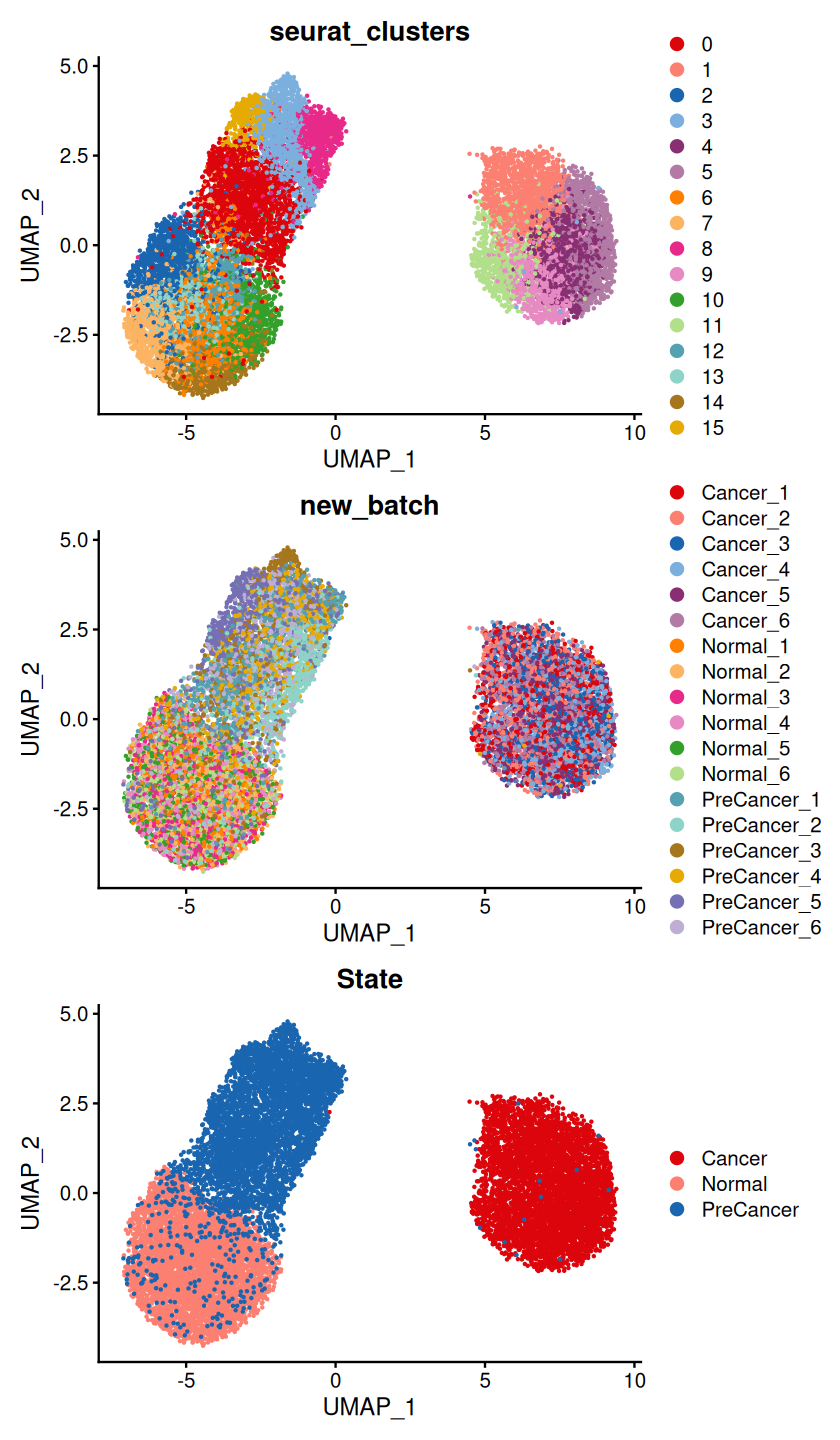

In [787]:
options(repr.plot.width =7, repr.plot.height=12)

DimPlot(seurat_sim,reduction = "umap",group.by = c("seurat_clusters","new_batch","State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

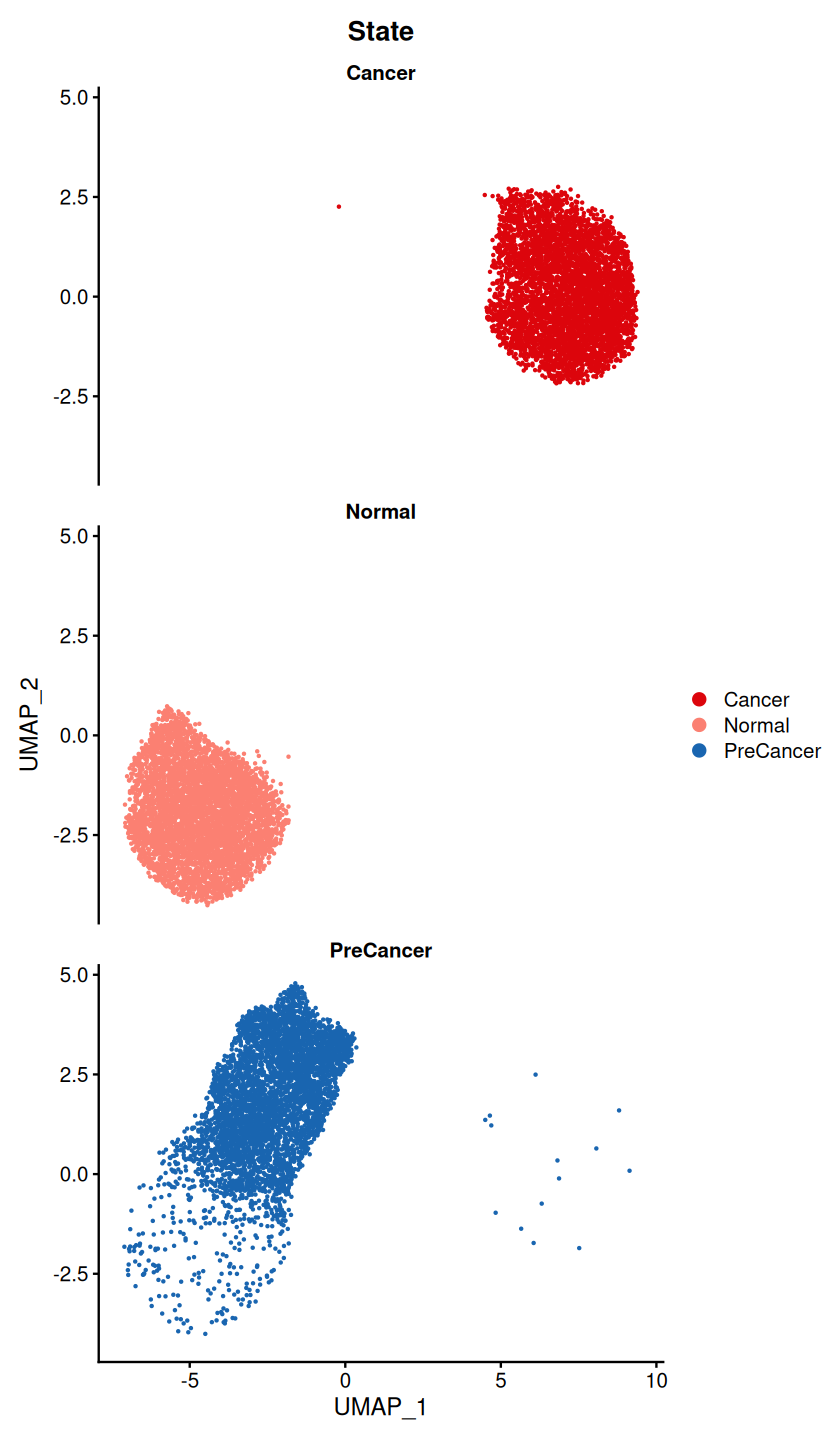

In [788]:
DimPlot(seurat_sim,reduction = "umap",group.by = c("State"),split.by = c("State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

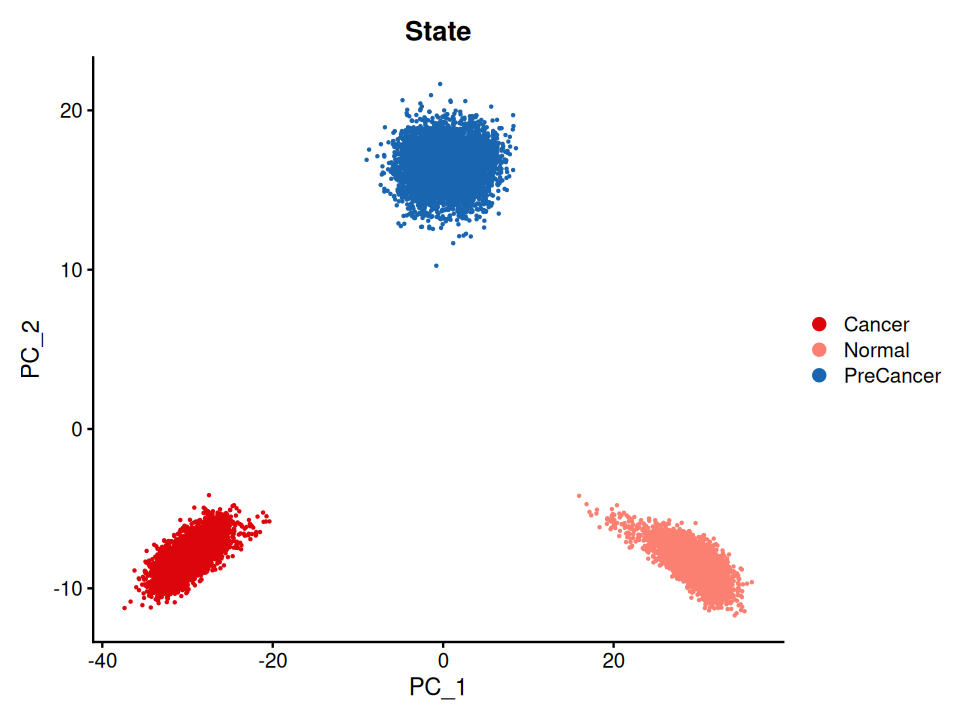

In [795]:
DimPlot(seurat_sim,reduction = "pca",group.by = c("State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

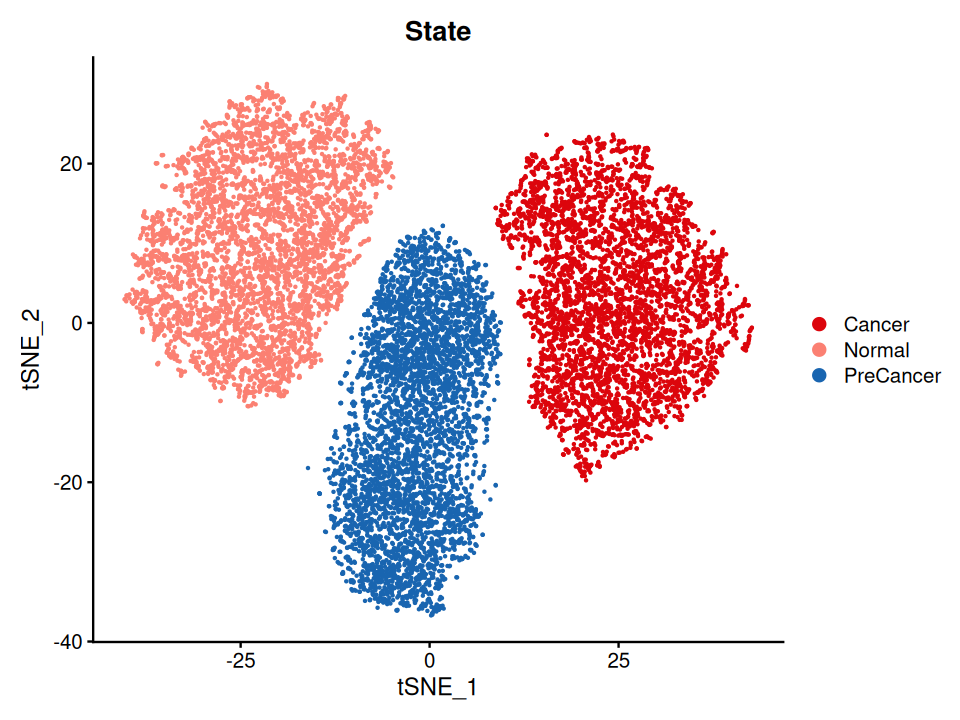

In [796]:
DimPlot(seurat_sim,reduction = "tsne",group.by = c("State"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))

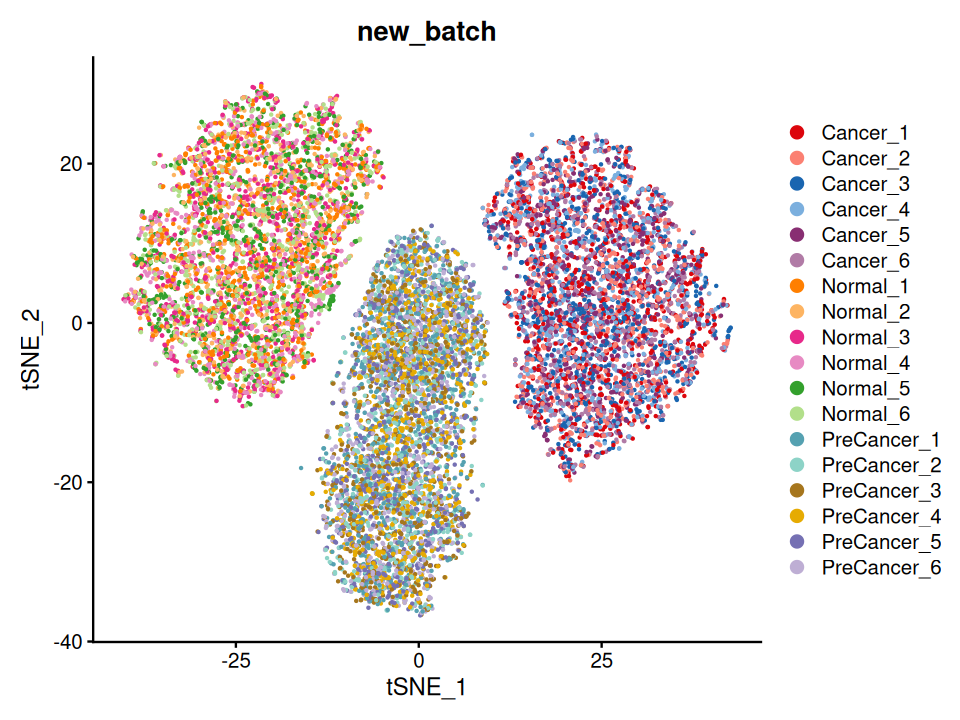

In [839]:
DimPlot(seurat_sim,reduction = "tsne",group.by = c("new_batch"),raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))